In [85]:
import matplotlib.pyplot as plt
import numpy as np

def plotar_grafo_normalizado(np_array, nome_coluna="Coluna", title="", xlabel="", labelnames=[]):
    # Conta os valores
    contagem = np_array.value_counts()

    # Normaliza
    proporcao = contagem / contagem.sum()

    # Ajusta as labels fornecidas
    if labelnames:
        proporcao.index = labelnames

    # Ordena alfabeticamente os índices
    proporcao = proporcao.sort_index()

    # Plota
    plt.figure(figsize=(10, 6))
    proporcao.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title(title or f'Distribuição da coluna {nome_coluna}')
    plt.xlabel(xlabel or nome_coluna)
    plt.ylabel('Proporção dos Casos')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()


def checar_nan(df_array, nome_coluna="Coluna", labelnames=[], nome_coluna_renomeado=None):
    np_array = df_array[nome_coluna]
    total = len(np_array)
    n_nan = np_array.isna().sum()
    perc_nan = (n_nan / total) * 100 if total > 0 else 0
    
    if n_nan > 0:
        print(f"Atenção: A coluna '{nome_coluna}' contém {n_nan} valores NaN.")
        print(f"Isso representa {perc_nan:.2f}% do total de {total} registros.")
    else:
        print(f"A coluna '{nome_coluna}' não contém valores NaN.")
        
    plotar_grafo_normalizado(np_array, nome_coluna=nome_coluna_renomeado or nome_coluna, labelnames=labelnames)

    


In [86]:
import pandas as pd
import os

# Diretório onde estão os arquivos CSV
caminho_diretorio = "data/csv_format/"
arquivos_csv = [f for f in os.listdir(caminho_diretorio) if f.endswith(".csv")]
dfs = [pd.read_csv(os.path.join(caminho_diretorio, arquivo), delimiter=',', dtype=str).assign(arquivo=arquivo) for arquivo in arquivos_csv]
df = pd.concat(dfs, ignore_index=True)
df.head()


,Unnamed: 0,TP_NOT,ID_AGRAVO,DT_NOTIFIC,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,DT_DIAG,ANO_NASC,...,AGRAVDROGA,AGRAVTABAC,TEST_MOLEC,TEST_SENSI,ANT_RETRO,BAC_APOS_6,TRANSF,UF_TRANSF,MUN_TRANSF,arquivo
0,0,2,A169,2001-01-04,2001,41,410420,1356,2001-01-04,1961,...,0,0,0,0,0,0,0,NaN,NaN,TUBEBR01.csv
1,1,2,A169,2001-02-20,2001,41,410690,1356,2001-02-20,1974,...,0,0,0,0,0,0,0,NaN,NaN,TUBEBR01.csv
2,2,2,A169,2001-01-12,2001,26,260570,1506,2001-01-12,1960,...,0,0,0,0,0,0,0,NaN,NaN,TUBEBR01.csv
3,3,2,A169,2001-02-23,2001,15,150140,1484,2001-02-23,1975,...,0,0,0,0,0,0,0,NaN,NaN,TUBEBR01.csv
4,4,2,A169,2001-01-05,2001,13,130120,0,2001-01-05,1975,...,0,0,0,0,0,0,0,NaN,NaN,TUBEBR01.csv


In [87]:
df["NU_ANO"]

0          2001
1          2001
2          2001
3          2001
4          2001
           ... 
2091706    2024
2091707    2024
2091708    2024
2091709    2024
2091710    2024
Name: NU_ANO, Length: 2091711, dtype: object

A coluna 'NU_ANO' não contém valores NaN.


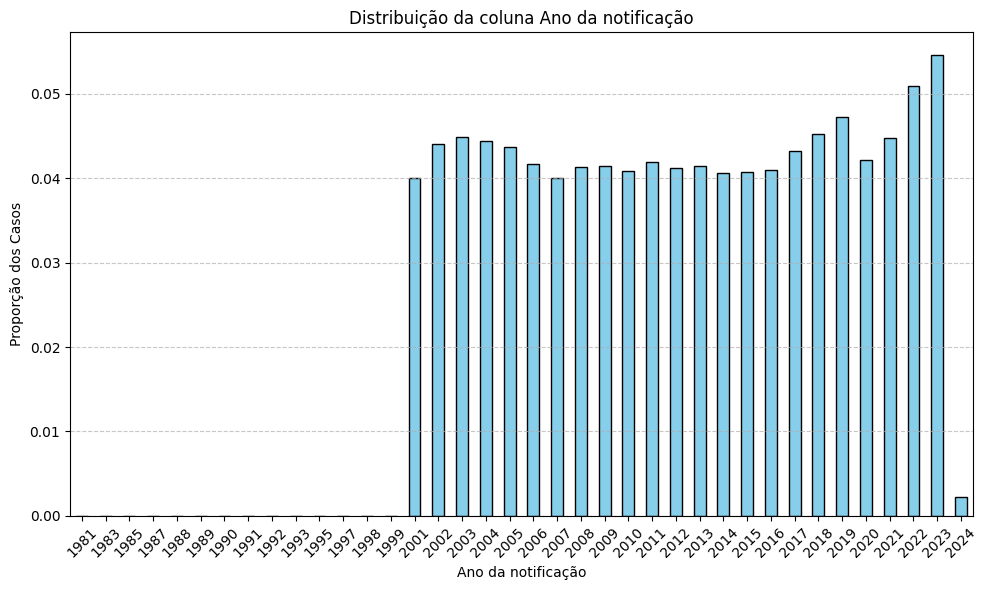

In [88]:
checar_nan(df, nome_coluna="NU_ANO", nome_coluna_renomeado="Ano da notificação")

In [89]:
df['NU_ANO'] = pd.to_numeric(df['NU_ANO'], errors='coerce')
df_filtra_ano = df[df['NU_ANO'].between(2019, 2023)]

df_filtra_ano.shape

(501562, 99)

In [90]:
df_filtra_ano.head()

,Unnamed: 0,TP_NOT,ID_AGRAVO,DT_NOTIFIC,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,DT_DIAG,ANO_NASC,...,AGRAVDROGA,AGRAVTABAC,TEST_MOLEC,TEST_SENSI,ANT_RETRO,BAC_APOS_6,TRANSF,UF_TRANSF,MUN_TRANSF,arquivo
180124,92859,2,A169,2020-03-18,2020,35,355030,0,2002-02-10,1964,...,1,2,5,7,0,0,0,NaN,NaN,TUBEBR02.csv
715334,86768,2,A169,2019-10-02,2019,35,355030,0,2008-10-01,1962,...,2,1,1,5,0,0,0,NaN,NaN,TUBEBR08.csv
801654,86319,2,A169,2019-01-02,2019,35,355030,0,2009-12-27,1970,...,2,1,1,7,0,0,0,NaN,NaN,TUBEBR09.csv
801655,86320,2,A169,2020-05-26,2020,35,355030,0,2009-06-15,1982,...,2,2,1,7,0,0,0,NaN,NaN,TUBEBR09.csv
887037,85381,2,A169,2019-04-18,2019,35,355030,0,2010-08-19,1983,...,1,1,1,5,1,0,0,NaN,NaN,TUBEBR10.csv


In [91]:
df_filtra_ano.columns

Index(['Unnamed: 0', 'TP_NOT', 'ID_AGRAVO', 'DT_NOTIFIC', 'NU_ANO',
       'SG_UF_NOT', 'ID_MUNICIP', 'ID_REGIONA', 'DT_DIAG', 'ANO_NASC',
       'NU_IDADE_N', 'CS_SEXO', 'CS_GESTANT', 'CS_RACA', 'CS_ESCOL_N', 'SG_UF',
       'ID_MN_RESI', 'ID_RG_RESI', 'ID_PAIS', 'NDUPLIC_N', 'IN_VINCULA',
       'DT_DIGITA', 'DT_TRANSUS', 'DT_TRANSDM', 'DT_TRANSSM', 'DT_TRANSRM',
       'DT_TRANSRS', 'DT_TRANSSE', 'CS_FLXRET', 'FLXRECEBI', 'MIGRADO_W',
       'ID_OCUPA_N', 'TRATAMENTO', 'INSTITUCIO', 'RAIOX_TORA', 'TESTE_TUBE',
       'FORMA', 'EXTRAPU1_N', 'EXTRAPU2_N', 'EXTRAPUL_O', 'AGRAVAIDS',
       'AGRAVALCOO', 'AGRAVDIABE', 'AGRAVDOENC', 'AGRAVOUTRA', 'AGRAVOUTDE',
       'BACILOSC_E', 'BACILOS_E2', 'BACILOSC_O', 'CULTURA_ES', 'CULTURA_OU',
       'HIV', 'HISTOPATOL', 'DT_INIC_TR', 'RIFAMPICIN', 'ISONIAZIDA',
       'ETAMBUTOL', 'ESTREPTOMI', 'PIRAZINAMI', 'ETIONAMIDA', 'OUTRAS',
       'OUTRAS_DES', 'TRAT_SUPER', 'NU_CONTATO', 'DOENCA_TRA', 'SG_UF_AT',
       'ID_MUNIC_A', 'DT_NOTI_AT', 'SG_

O campo a seguir que sinaliza se houve óbito ou cura:

### 🔹 `SITUA_ENCE` — Situação de encerramento

Conforme o dicionário de dados do SINAN para tuberculose:

| Valor | Descrição                         | 
|-------|-----------------------------------|
| 1     | Cura                              |
| 2     | Abandono                          |
| 3     | Óbito por Tuberculose             |
| 4     | Óbito por outras causas           |
| 5     | Transferência                     |
| 6     | Mudança de diagnóstico            |
| 7     | TB resistente (TB-DR)             |
| 8     | Mudança de esquema terapêutico    |
| 9     | Falência                          |
| 10    | Abandono primário                 |

Atenção: A coluna 'SITUA_ENCE' contém 27209 valores NaN.
Isso representa 5.42% do total de 501562 registros.


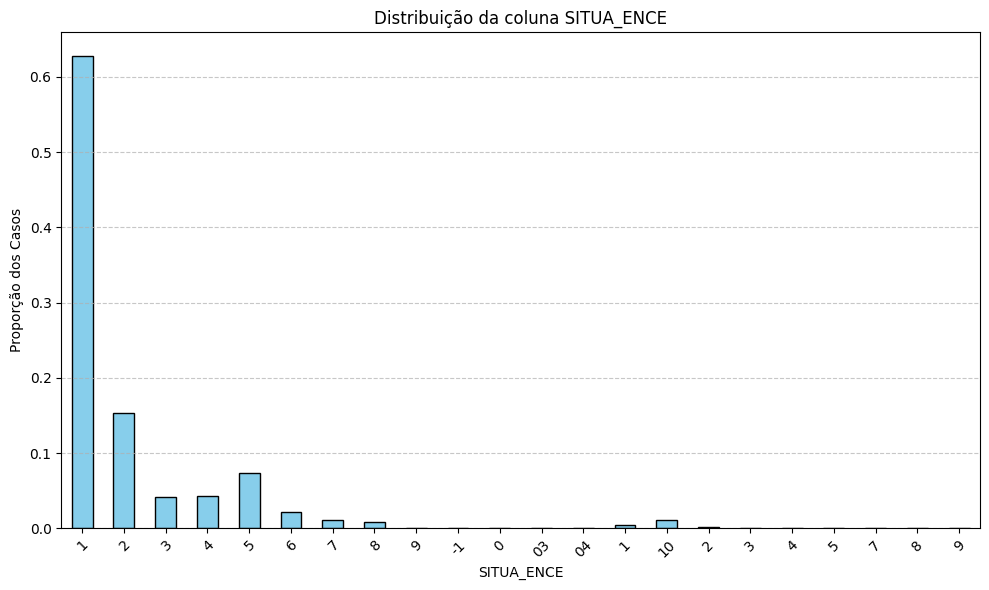

In [92]:
checar_nan(df_filtra_ano, nome_coluna="SITUA_ENCE")


Agora, vamos filtrar para dois casos: Para a coluna igual a 1 ela vai se tornar uma instância de cura de um paciente, para a coluna 3 vai ser considerado os óbitos pela tuberculose.

A coluna 'SITUACAO_AGRUPADA' não contém valores NaN.


C:\Users\Maria\AppData\Local\Temp\ipykernel_19768\3673982393.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtra_ano.loc[:, 'SITUACAO_AGRUPADA'] = df_filtra_ano['SITUA_ENCE'].apply(agrupar_situacao)


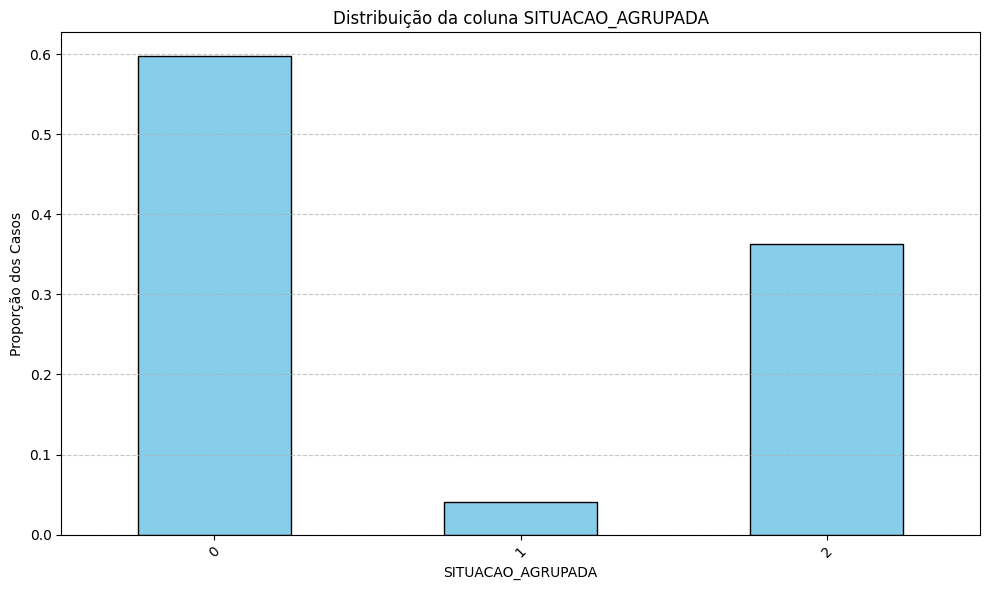

In [93]:
def agrupar_situacao(codigo):
    try:
        if pd.isna(codigo):
            return 2
        codigo = int(float(codigo))  # converte para int, mesmo que venha como float tipo 1.0
        if codigo == 1:
            return 0
        elif codigo == 3:
            return 1
        else:
            return 2
    except:
        print(f'Erro ao processar: {codigo}')
        return 'Outro'


df_filtra_ano.loc[:, 'SITUACAO_AGRUPADA'] = df_filtra_ano['SITUA_ENCE'].apply(agrupar_situacao)

checar_nan(df_filtra_ano, nome_coluna="SITUACAO_AGRUPADA")


Agora, removemos a coluna original e os casos que 'SITUA_ENCE' = 2 

In [94]:
df_filtra_ano = df_filtra_ano.drop(columns=['SITUA_ENCE'])

df_filtra_ano = df_filtra_ano[df_filtra_ano['SITUACAO_AGRUPADA'] != 2]

A coluna 'SITUACAO_AGRUPADA' não contém valores NaN.


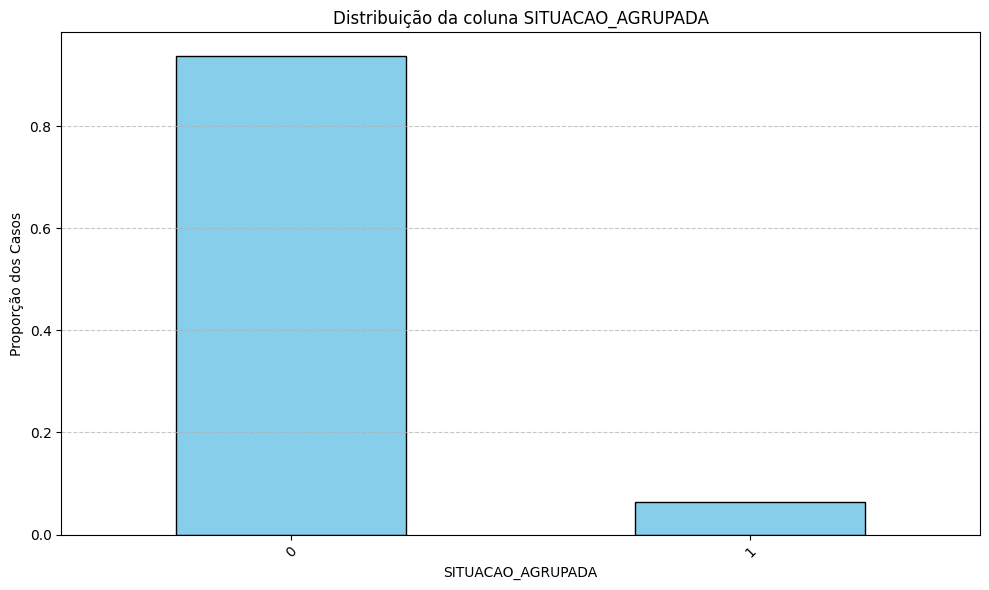

In [95]:
checar_nan(df_filtra_ano, nome_coluna="SITUACAO_AGRUPADA")

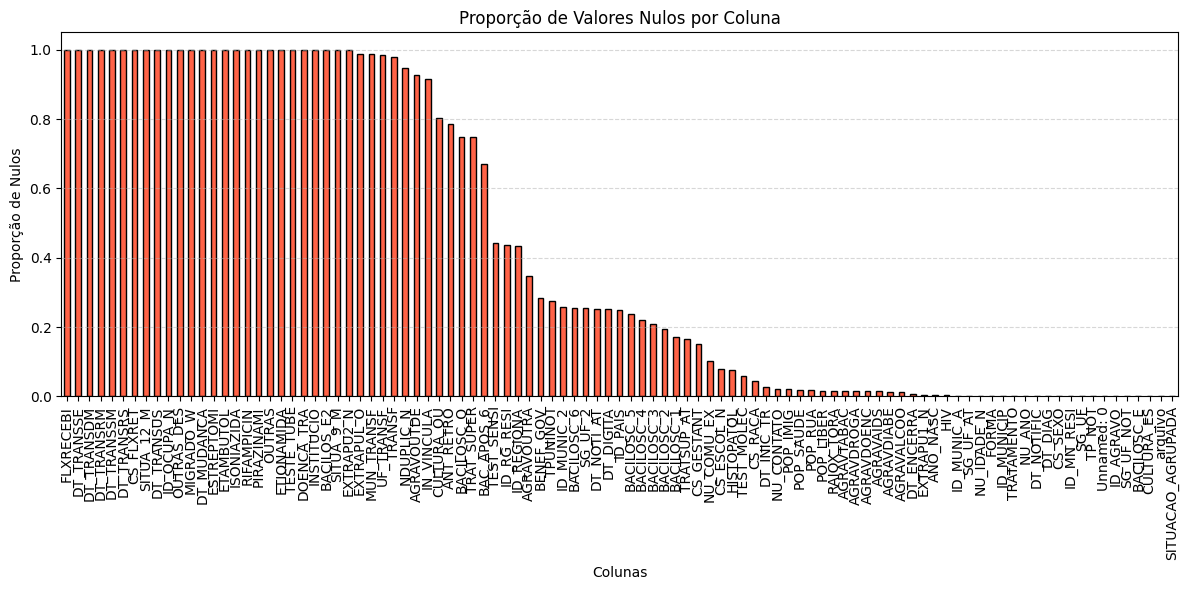

In [96]:
# a gente tentou cortar as colunas com mais componentes nulos

import matplotlib.pyplot as plt

# Calcula a proporção de valores nulos por coluna
null_ratios = df_filtra_ano.isna().mean()

# Plota o histograma (gráfico de barras)
plt.figure(figsize=(12, 6))
plt.rcParams.update({'font.size': 10})
null_ratios.sort_values(ascending=False).plot(kind='bar', color='tomato', edgecolor='black')

plt.title('Proporção de Valores Nulos por Coluna')
plt.xlabel('Colunas')
plt.ylabel('Proporção de Nulos')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


Vamos remover os casos com mais de 60% de valores vazios, para remover essas colunas com excesso de elementos vazios:

In [97]:
threshold = 0.6

empty_ratio = df_filtra_ano.isna().mean()

columns_to_drop = empty_ratio[empty_ratio > threshold].index

df_cleaned_columns = df_filtra_ano.copy()
df_cleaned_columns = df_cleaned_columns.drop(columns=columns_to_drop)

df_cleaned_columns.head()

,Unnamed: 0,TP_NOT,ID_AGRAVO,DT_NOTIFIC,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,DT_DIAG,ANO_NASC,...,POP_RUA,POP_SAUDE,POP_IMIG,BENEF_GOV,AGRAVDROGA,AGRAVTABAC,TEST_MOLEC,TEST_SENSI,arquivo,SITUACAO_AGRUPADA
180124,92859,2,A169,2020-03-18,2020,35,355030,0,2002-02-10,1964,...,2,2,2,0,1,2,5,7,TUBEBR02.csv,0
715334,86768,2,A169,2019-10-02,2019,35,355030,0,2008-10-01,1962,...,2,2,2,0,2,1,1,5,TUBEBR08.csv,0
801654,86319,2,A169,2019-01-02,2019,35,355030,0,2009-12-27,1970,...,1,2,2,0,2,1,1,7,TUBEBR09.csv,1
801655,86320,2,A169,2020-05-26,2020,35,355030,0,2009-06-15,1982,...,2,2,3,0,2,2,1,7,TUBEBR09.csv,0
887037,85381,2,A169,2019-04-18,2019,35,355030,0,2010-08-19,1983,...,2,2,2,0,1,1,1,5,TUBEBR10.csv,0


Agora vamos olhar coluna por coluna

**TP_NOT**<br>
1 – Negativa <br>
2 – Individual <br>
3 – Surto <br>
4 – Agregado <br>
Utilidade: Identifica o tipo da notificação

A coluna 'TP_NOT' não contém valores NaN.


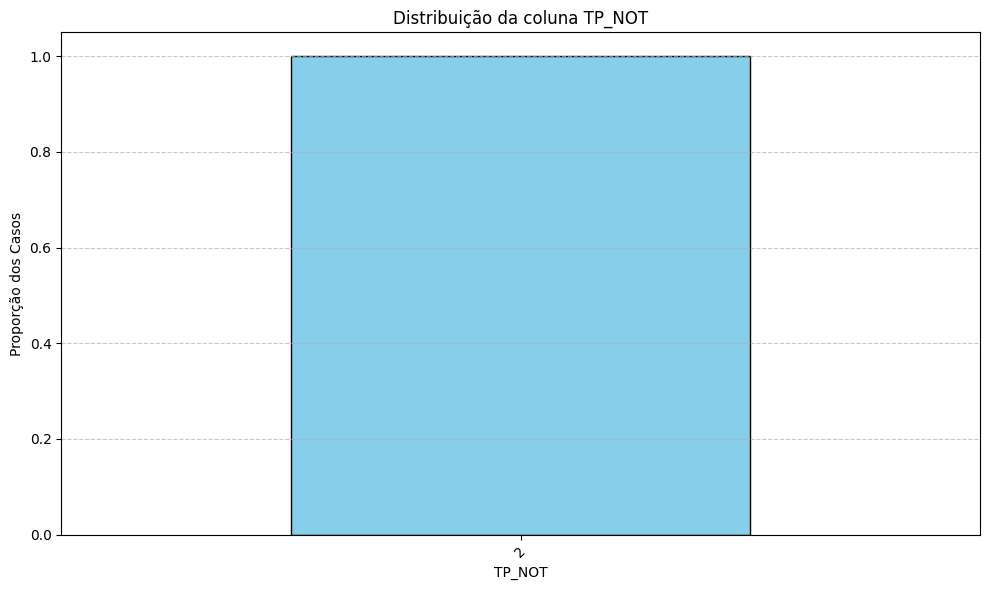

In [98]:
checar_nan(df_filtra_ano, nome_coluna="TP_NOT")

Como há apenas uma categoria relevantes, vamos remover **TP_NOT**

In [99]:
df_cleaned_columns = df_cleaned_columns.drop(columns=["TP_NOT"])

**ID_AGRAVO** <br> 
Tabela de agravos do sistema com códigos (classificação 
internacional de doenças – CID 10) e nomes dos agravos 
classificados como notificação compulsória (nacional, 
estadual ou municipal) e as síndromes (febre hemorragia 
aguda; respiratória aguda; diarréia aguda; sanguinolenta; 
neurológica aguda; insuficiência renal aguda; outras 
síndromes. <br>
Nome e código do agravo notificado 
segundo CID-10 (Centro Colaborador da 
OMS para a Classificação de Doenças 
em Português) <br>

A coluna 'ID_AGRAVO' não contém valores NaN.


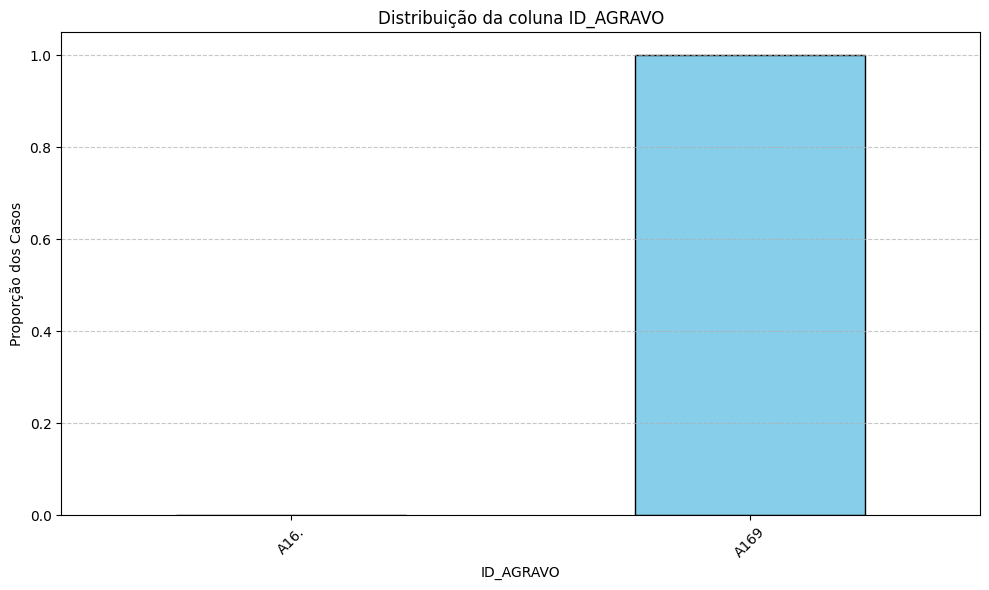

In [100]:
checar_nan(df_cleaned_columns, nome_coluna="ID_AGRAVO")


Como há apenas uma categoria relevantes, vamos remover **ID_AGRAVO**

In [101]:
df_cleaned_columns = df_cleaned_columns[df_cleaned_columns['ID_AGRAVO'] != 'A16.']
df_cleaned_columns = df_cleaned_columns.drop(columns=["ID_AGRAVO"])

### Removendo colunas que se referem a exames
**BACILOSC** (E, 1, 2, 3, 4, 5, 6) - varchar2(1) <br>
Baciloscopia
1- Positiva <br>
2- Negativa <br>
3- Não realizada <br>
4- Não se aplica <br>
<br>

**RAIOX_TORA** - varchar2(1) <br>
Radiografia do Tórax <br>
1- Suspeito <br>
2- Normal <br>
3- Outra patologia <br>
4- Não realizado <br>
<br>

**HIV** - varchar2(1) <br>
1- Positivo <br>
2- Negativo <br>
3- Em andamento <br>
4- Não realizado <br>
<br>

**HISTOPATOL** - varchar2(1) <br>
1- Baar Positivo <br>
2- Sugestivo de TB <br>
3- Não sugestivo de TB <br>
4- Em andamento <br>
5- Não realizado <br>
<br>

**CULTURA_ES** - varchar2(1) <br>
Cultura de Escarro
1- Positivo <br>
2- Negativo <br>
3- Em andamento <br>
4- Não realizado <br>
<br>

A coluna 'BACILOSC_E' não contém valores NaN.


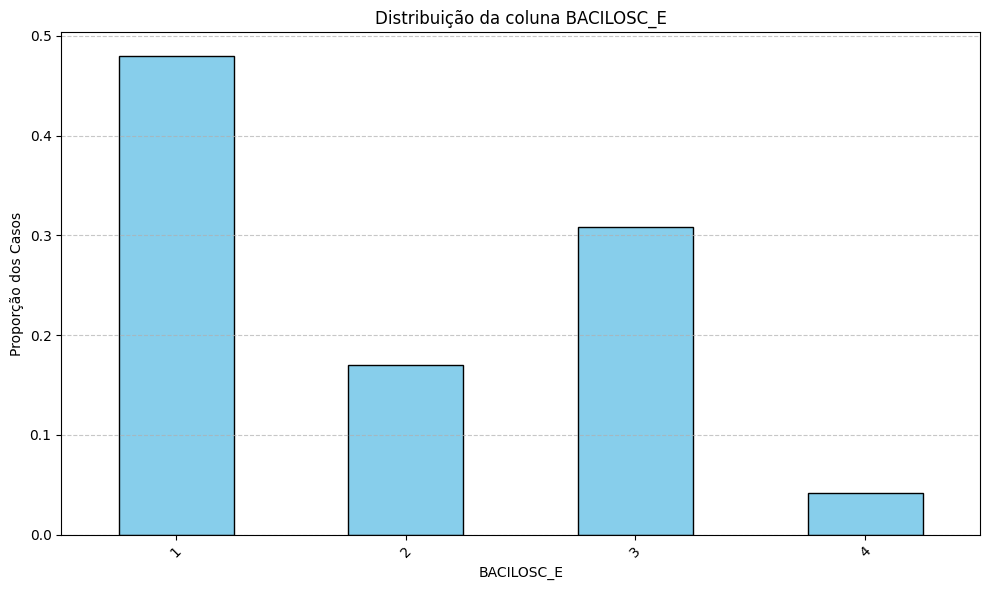

Atenção: A coluna 'BACILOSC_1' contém 54945 valores NaN.
Isso representa 17.18% do total de 319799 registros.


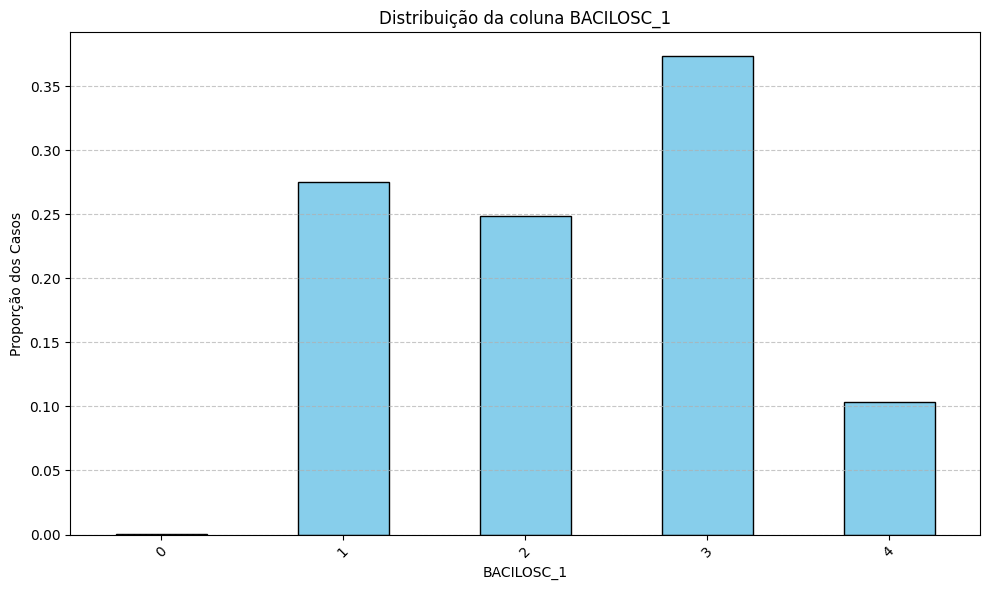

Atenção: A coluna 'BACILOSC_2' contém 62293 valores NaN.
Isso representa 19.48% do total de 319799 registros.


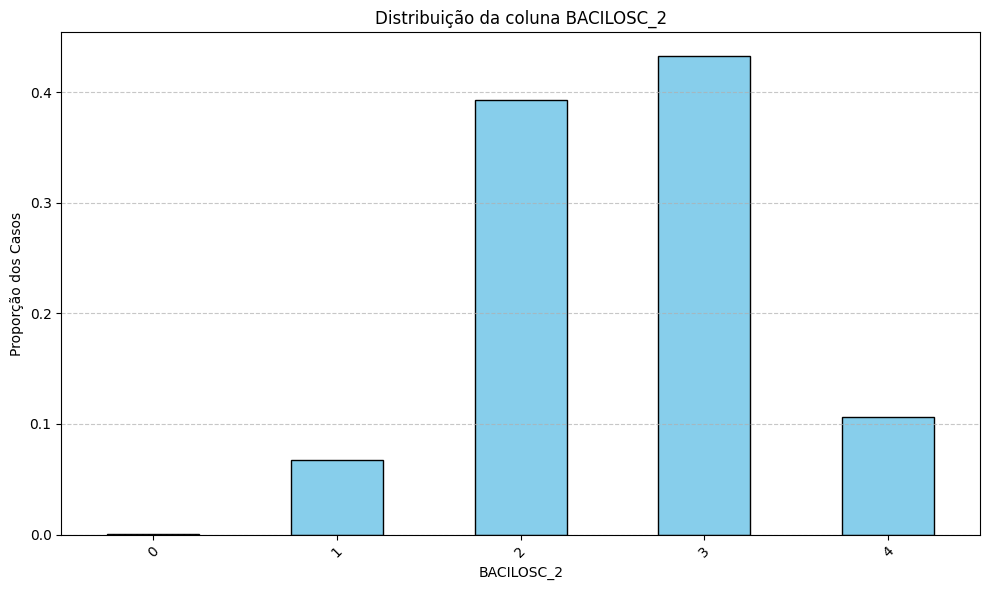

Atenção: A coluna 'BACILOSC_3' contém 67139 valores NaN.
Isso representa 20.99% do total de 319799 registros.


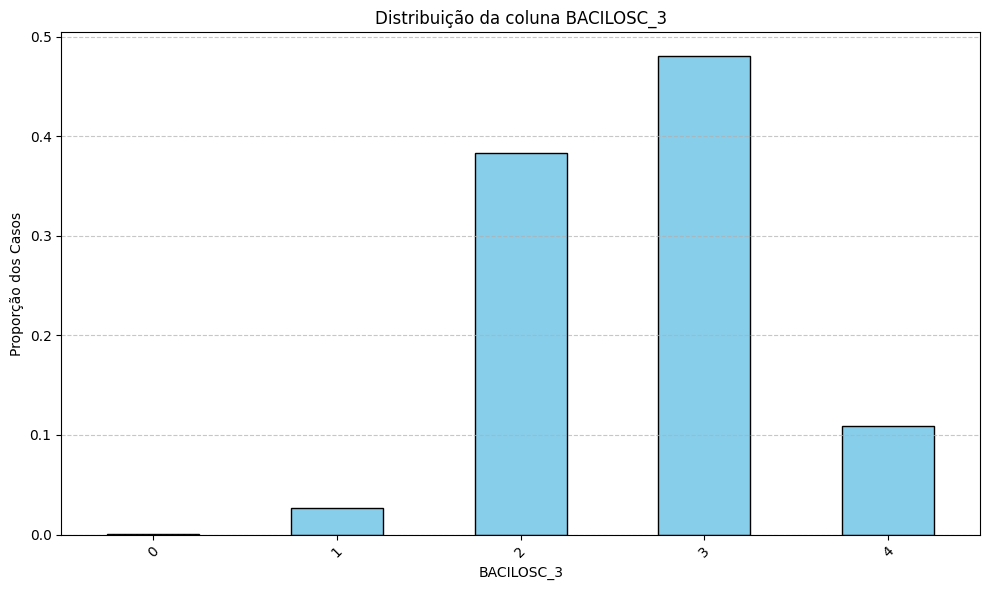

Atenção: A coluna 'BACILOSC_4' contém 70840 valores NaN.
Isso representa 22.15% do total de 319799 registros.


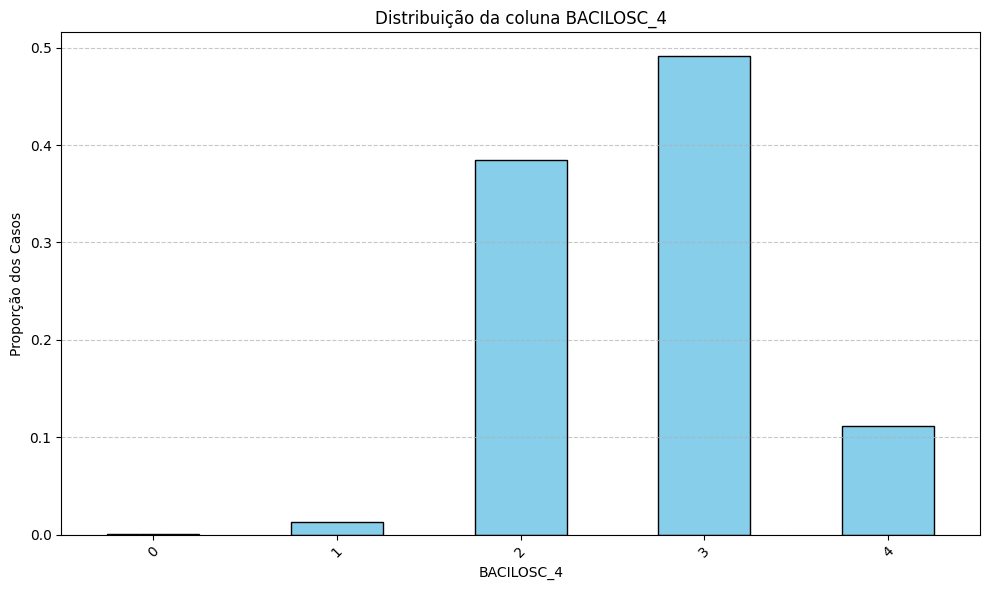

Atenção: A coluna 'BACILOSC_5' contém 76018 valores NaN.
Isso representa 23.77% do total de 319799 registros.


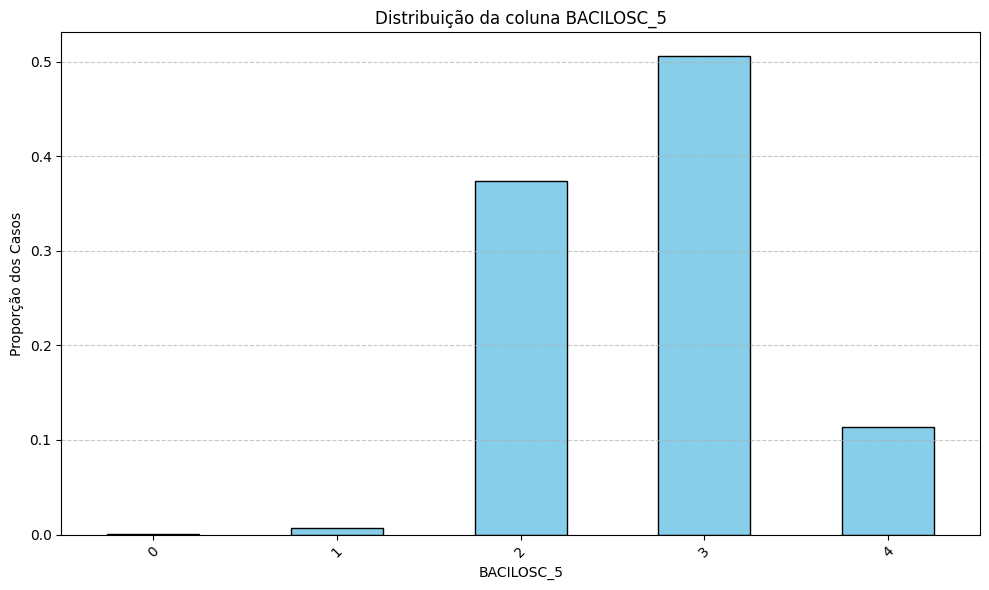

Atenção: A coluna 'BACILOSC_6' contém 81775 valores NaN.
Isso representa 25.57% do total de 319799 registros.


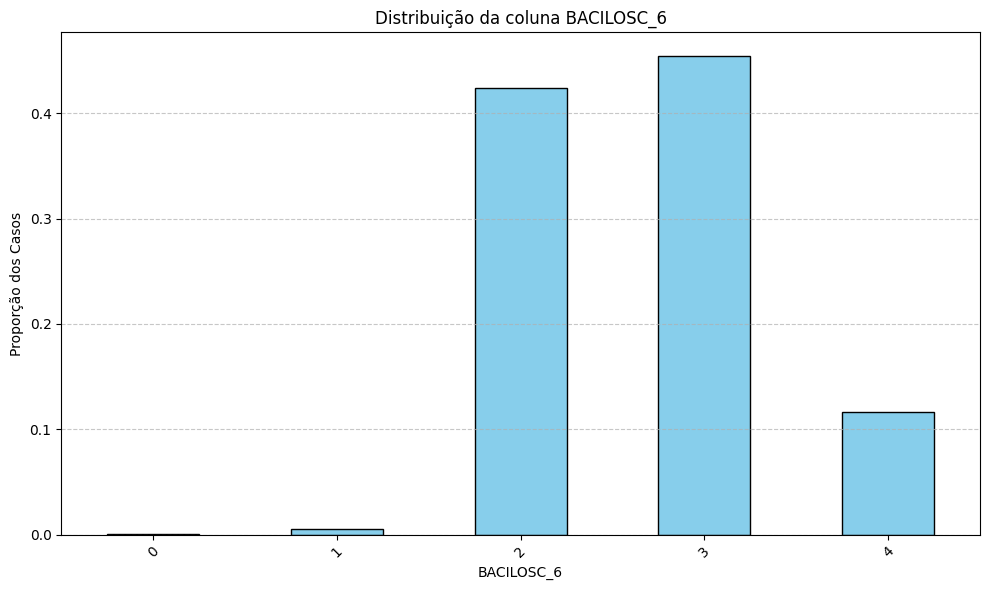

Atenção: A coluna 'RAIOX_TORA' contém 5124 valores NaN.
Isso representa 1.60% do total de 319799 registros.


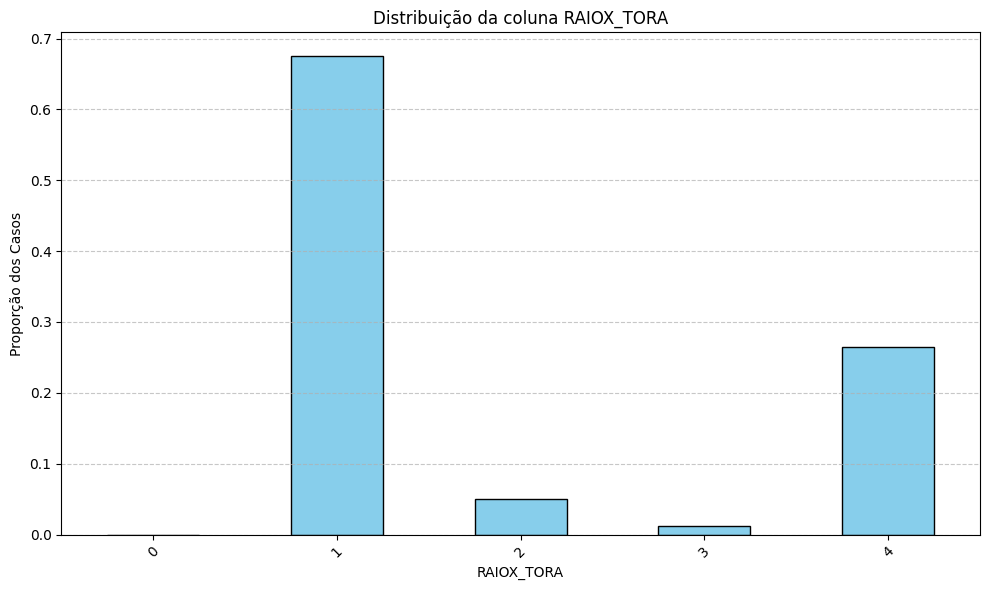

Atenção: A coluna 'HIV' contém 993 valores NaN.
Isso representa 0.31% do total de 319799 registros.


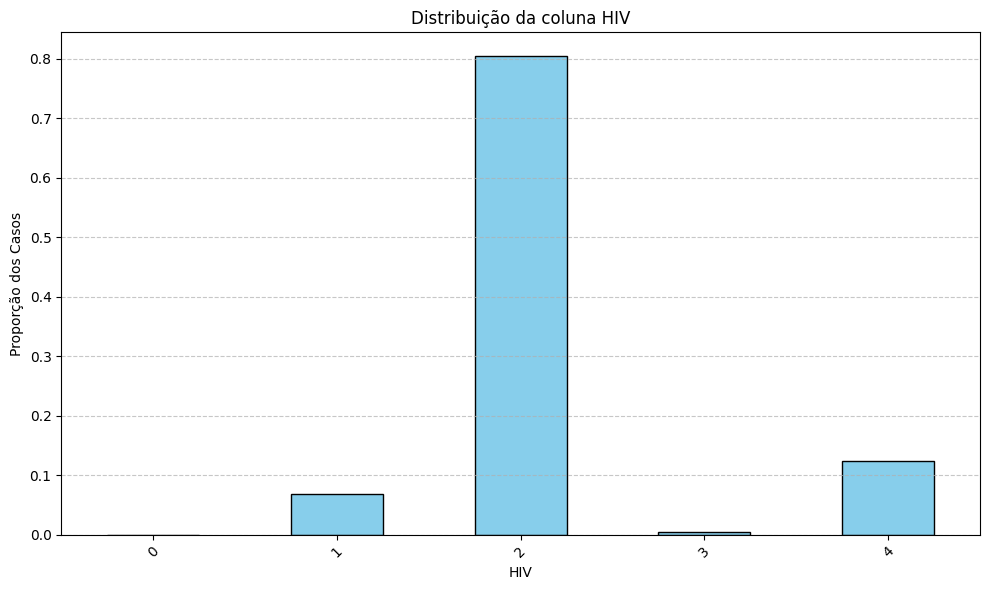

Atenção: A coluna 'HISTOPATOL' contém 24479 valores NaN.
Isso representa 7.65% do total de 319799 registros.


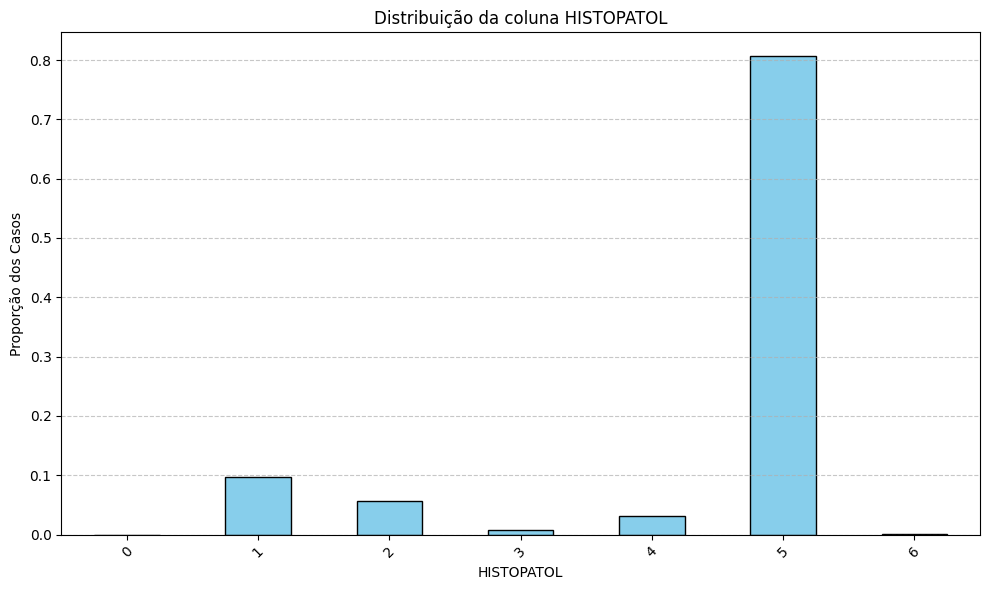

A coluna 'CULTURA_ES' não contém valores NaN.


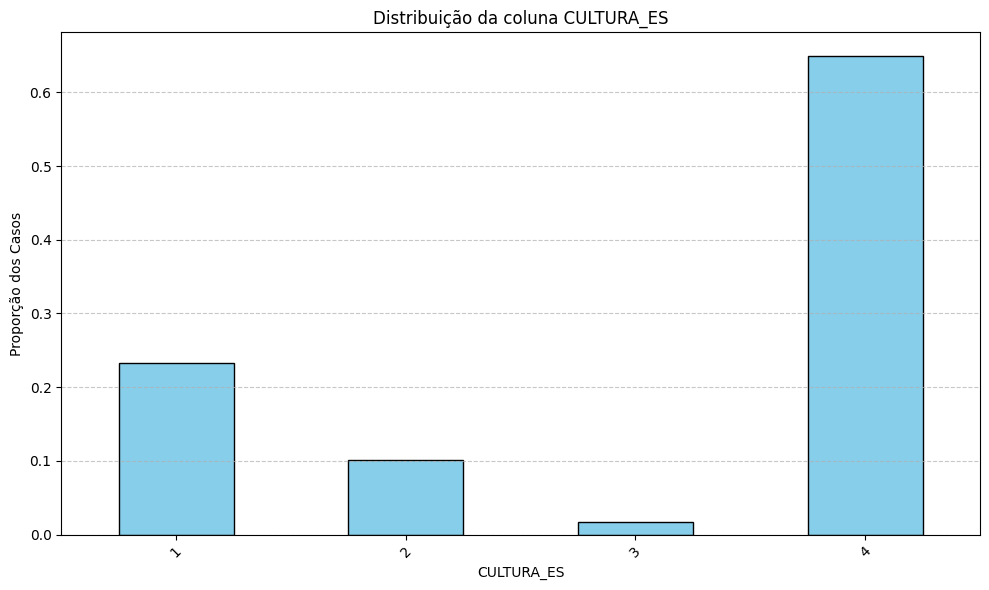

In [102]:
# Lista das colunas a serem removidas
colunas_para_dropar = [
    'BACILOSC_E', 'BACILOSC_1', 'BACILOSC_2', 'BACILOSC_3', 'BACILOSC_4', 'BACILOSC_5', 'BACILOSC_6', 'RAIOX_TORA', 'HIV', 'HISTOPATOL', 
    'CULTURA_ES', 
]

for coluna in colunas_para_dropar:
    checar_nan(df_cleaned_columns, nome_coluna=coluna)
    df_cleaned_columns = df_cleaned_columns.drop(columns=coluna)

**TEST_SENSI** - varchar2(1) <br>
Teste de sensibilidade <br>
1. Resistente somente à Isoniazida <br>
2. Resistente somente à Rifampicina <br>
3. Resistente à Isoniazida e Rifampicina <br>
4. Resistente a outras drogas de 1ªlinha <br>
5. Sensível <br>
6. Em andamento <br>
7. Não realizado <br>

**TEST_MOLEC** - varchar2(1) <br>
Teste molecular rápido (tb) <br>
1. Detectável sensível à Rifampicina <br>
2. Detectável resistente à Rifampicina<br>
3. Não detectável<br>
4. Inconclusivo<br>
5. Não realizado<br>

Atenção: A coluna 'TEST_SENSI' contém 141588 valores NaN.
Isso representa 44.27% do total de 319799 registros.


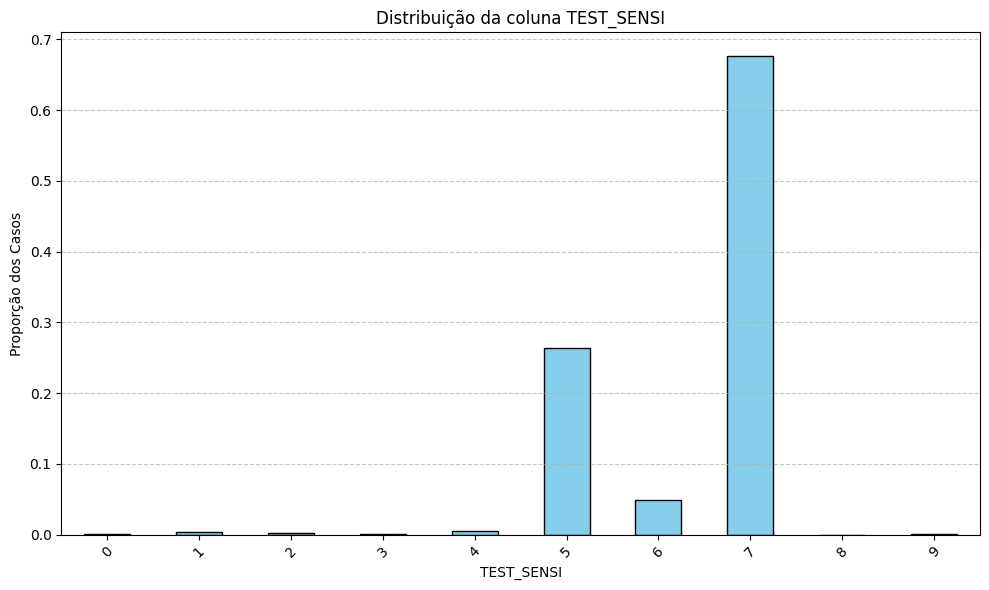

Atenção: A coluna 'TEST_MOLEC' contém 18786 valores NaN.
Isso representa 5.87% do total de 319799 registros.


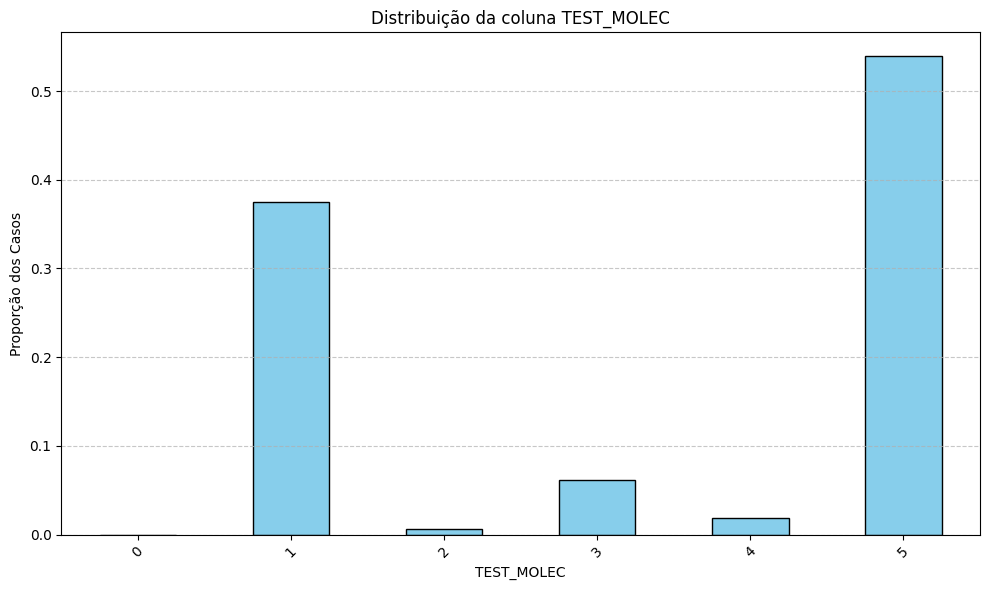

In [103]:
checar_nan(df_cleaned_columns, nome_coluna="TEST_SENSI")
checar_nan(df_cleaned_columns, nome_coluna="TEST_MOLEC")

In [104]:
df_cleaned_columns = df_cleaned_columns.drop(columns="TEST_SENSI")
df_cleaned_columns = df_cleaned_columns.drop(columns="TEST_MOLEC")

In [105]:
df_cleaned_columns.columns

Index(['Unnamed: 0', 'DT_NOTIFIC', 'NU_ANO', 'SG_UF_NOT', 'ID_MUNICIP',
       'ID_REGIONA', 'DT_DIAG', 'ANO_NASC', 'NU_IDADE_N', 'CS_SEXO',
       'CS_GESTANT', 'CS_RACA', 'CS_ESCOL_N', 'SG_UF', 'ID_MN_RESI',
       'ID_RG_RESI', 'ID_PAIS', 'DT_DIGITA', 'TRATAMENTO', 'FORMA',
       'EXTRAPU1_N', 'AGRAVAIDS', 'AGRAVALCOO', 'AGRAVDIABE', 'AGRAVDOENC',
       'AGRAVOUTRA', 'DT_INIC_TR', 'NU_CONTATO', 'SG_UF_AT', 'ID_MUNIC_A',
       'DT_NOTI_AT', 'SG_UF_2', 'ID_MUNIC_2', 'TRATSUP_AT', 'NU_COMU_EX',
       'DT_ENCERRA', 'TPUNINOT', 'POP_LIBER', 'POP_RUA', 'POP_SAUDE',
       'POP_IMIG', 'BENEF_GOV', 'AGRAVDROGA', 'AGRAVTABAC', 'arquivo',
       'SITUACAO_AGRUPADA'],
      dtype='object')

**SG_UF_NOT**<br>
UF de Notificação<br> Tabela com Códigos e siglas padronizados pelo IBGE <br>
Sigla da Unidade Federativa onde está 
localizada a unidade de saúde (ou outra 
fonte notificadora) que realizou a 
notificação. A sigla é uma variável que 
está associada ao código na tabela.

A coluna 'SG_UF_NOT' não contém valores NaN.


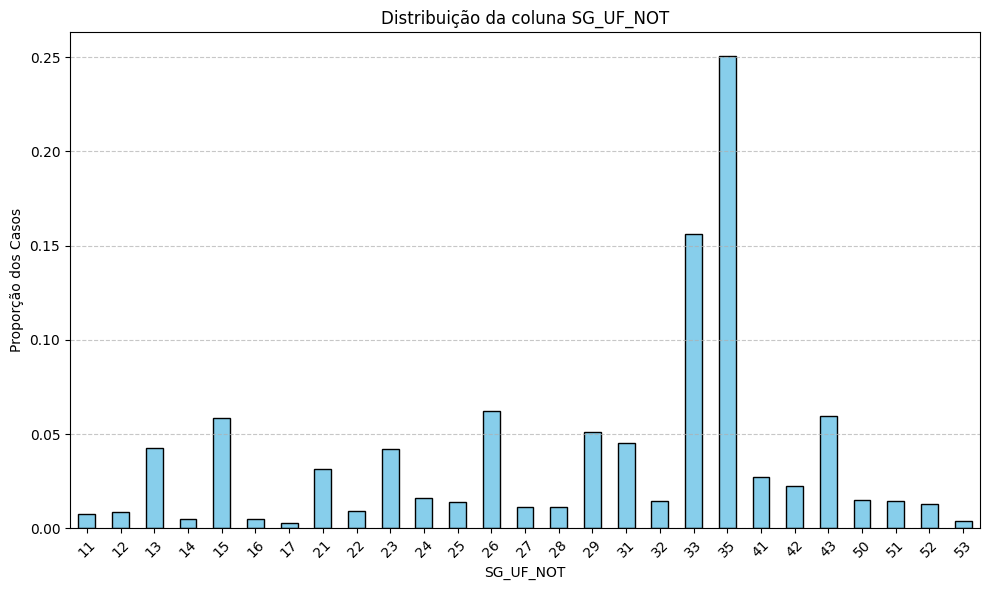

In [106]:
checar_nan(df_cleaned_columns, nome_coluna="SG_UF_NOT")


Vamos remover a coluna **SG_UF_NOT**, para criar **REGIAO**, que vai agrupar por região brasileira ao invés de unidade federativa

A coluna 'REGIAO' não contém valores NaN.


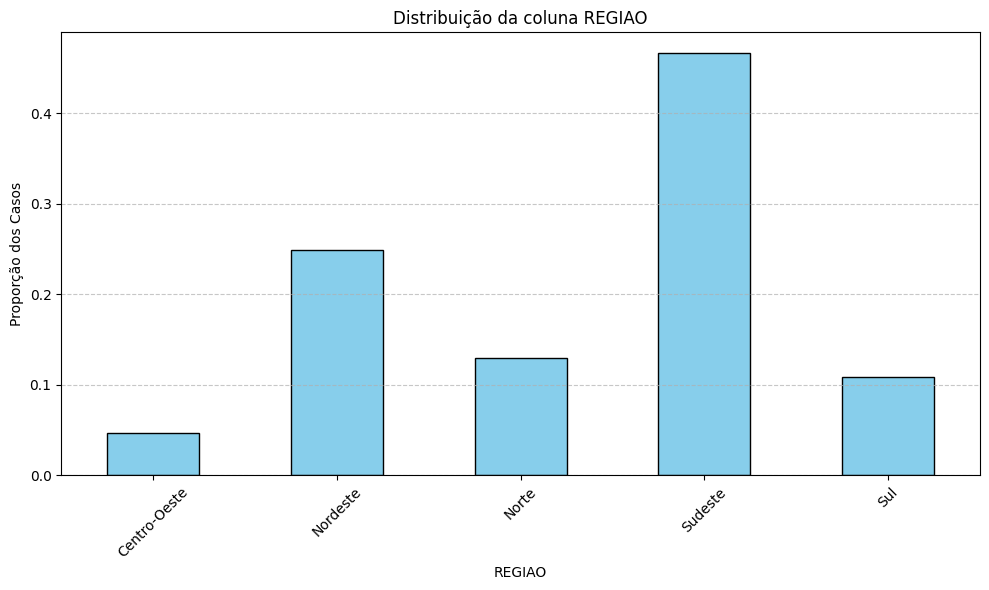

In [107]:
# Dicionário de UFs por região
regioes = {
    # Norte
    12: 'Norte', 16: 'Norte', 13: 'Norte', 11: 'Norte', 14: 'Norte',
    15: 'Norte', 17: 'Norte',

    # Nordeste
    21: 'Nordeste', 22: 'Nordeste', 23: 'Nordeste', 24: 'Nordeste',
    25: 'Nordeste', 26: 'Nordeste', 27: 'Nordeste', 28: 'Nordeste',
    29: 'Nordeste',

    # Centro-Oeste
    50: 'Centro-Oeste', 51: 'Centro-Oeste', 52: 'Centro-Oeste', 53: 'Centro-Oeste',

    # Sudeste
    31: 'Sudeste', 32: 'Sudeste', 33: 'Sudeste', 35: 'Sudeste',

    # Sul
    41: 'Sul', 42: 'Sul', 43: 'Sul'
}

# Cria uma nova coluna com o nome da região
df_cleaned_columns["SG_UF_NOT"] = df_cleaned_columns["SG_UF_NOT"].astype(int)
df_cleaned_columns["REGIAO"] = df_cleaned_columns["SG_UF_NOT"].map(regioes)

df_cleaned_columns = df_cleaned_columns.drop(columns=['SG_UF_NOT'])
df_cleaned_columns = df_cleaned_columns.drop(columns=['SG_UF'])

checar_nan(df_cleaned_columns, nome_coluna="REGIAO")


**ID_MUNICIP** <br>
Município de Notificação <br>Tabela com Código e nome dos municípios do cadastro do 
IBGE (tabela municipi.dbf) <br>
Código do município onde está 
localizada a unidade de saúde (ou outra 
fonte notificadora) que realizou a 
notificação. O nome está associado ao 
código na tabela de municípios.

Atenção: A coluna 'ID_MUNICIP' contém 1 valores NaN.
Isso representa 0.00% do total de 319799 registros.


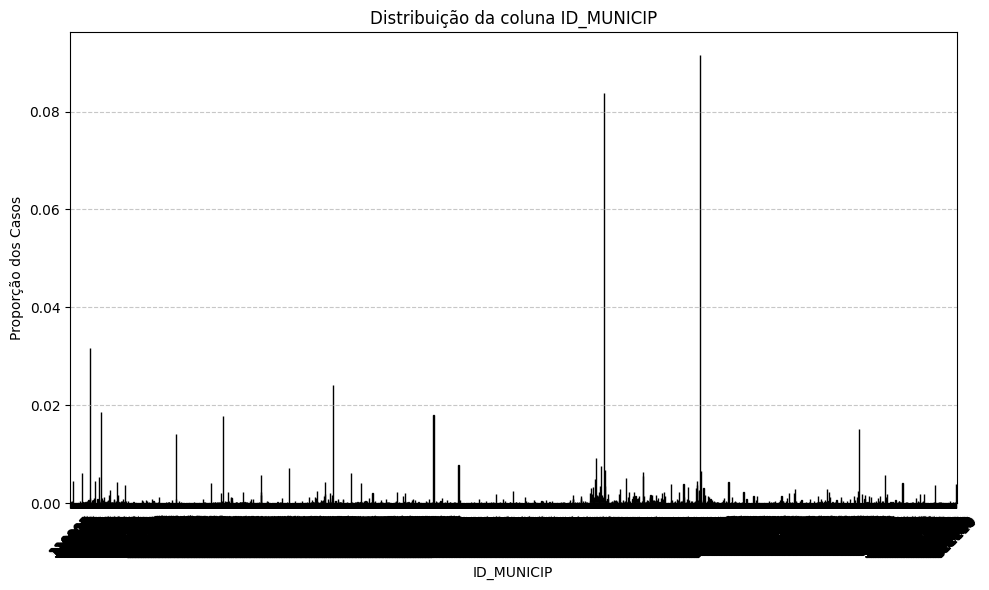

In [108]:
checar_nan(df_cleaned_columns, nome_coluna="ID_MUNICIP")

Vamos dar drop em **ID_MUNICIP**,e as outras colunas de municipio, porque já temos a coluna **REGIAO** para representar dados geográficos, e por **ID_MUNICIP** ter granularidade demais.

In [109]:
df_cleaned_columns = df_cleaned_columns.drop(columns=["ID_MUNICIP"])
df_cleaned_columns = df_cleaned_columns.drop(columns=["ID_MUNIC_2"])
df_cleaned_columns = df_cleaned_columns.drop(columns=["ID_MUNIC_A"])
df_cleaned_columns = df_cleaned_columns.drop(columns=["ID_REGIONA"])

**NU_IDADE_N**<br>Idade <br>
A composição da variável obedece ao seguinte critério: 1o 
dígito:<br> <br>
1 – Hora <br>
2 – Dia <br>
3 – Mês <br>
4 – Ano <br>
 <br>
Ex: 3009 – nove meses, 4018 – dezoito anos <br>
Quando não há data de nascimento a 
idade deve ser digitada segundo 
informação fornecida pelo paciente 
como aquela referida por ocasião da 
data dos primeiros sintomas ou na falta 
desse dado é registrada a idade 
aparente. <br>

Realizando a transformação para encontrar uma coluna de idade:

Atenção: A coluna 'NU_IDADE_N' contém 91 valores NaN.
Isso representa 0.03% do total de 319799 registros.


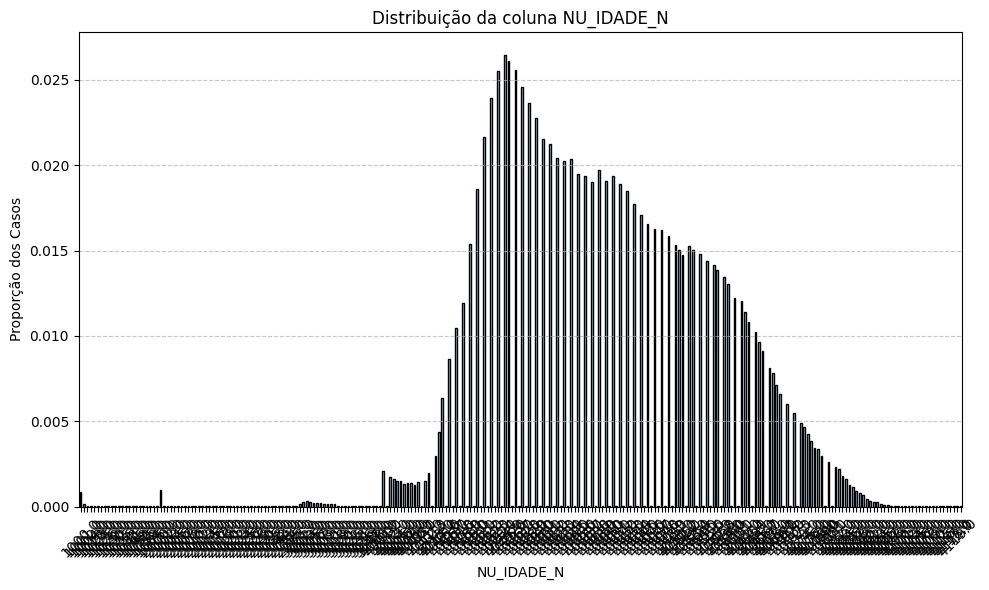

In [110]:
checar_nan(df_cleaned_columns, nome_coluna="NU_IDADE_N")

In [111]:
import numpy as np

# Função para converter idade para anos
def idade_em_anos(valor):
    try:
        valor = int(float(valor))  # Ex: 4023.0 -> 4023
        unidade = valor // 1000    # 4 em 4023 (anos)
        quantidade = valor % 1000  # 23 em 4023

        if unidade == 1:  # horas
            return quantidade / (24 * 365)
        elif unidade == 2:  # dias
            return quantidade / 365
        elif unidade == 3:  # meses
            return quantidade / 12
        elif unidade == 4:  # anos
            return quantidade
        else:
            return np.nan
    except:
        return np.nan

df_cleaned_columns["IDADE_ANOS"] = df_cleaned_columns["NU_IDADE_N"].apply(idade_em_anos)
df_cleaned_columns = df_cleaned_columns.drop(columns=["NU_IDADE_N"])

df_cleaned_columns["IDADE_ANOS"] = df_cleaned_columns["IDADE_ANOS"].round().astype("Int64")
df_cleaned_columns = df_cleaned_columns[df_cleaned_columns["IDADE_ANOS"].between(16, 110)]

print(f"Total final de registros com idade válida: {len(df_cleaned_columns)}")

Total final de registros com idade válida: 307851


In [112]:
df_cleaned_columns["IDADE_ANOS"].value_counts()

IDADE_ANOS
24     8466
25     8345
26     8181
23     8164
27     7871
       ... 
108       1
107       1
105       1
106       1
110       1
Name: count, Length: 95, dtype: Int64

A coluna 'IDADE_ANOS' não contém valores NaN.


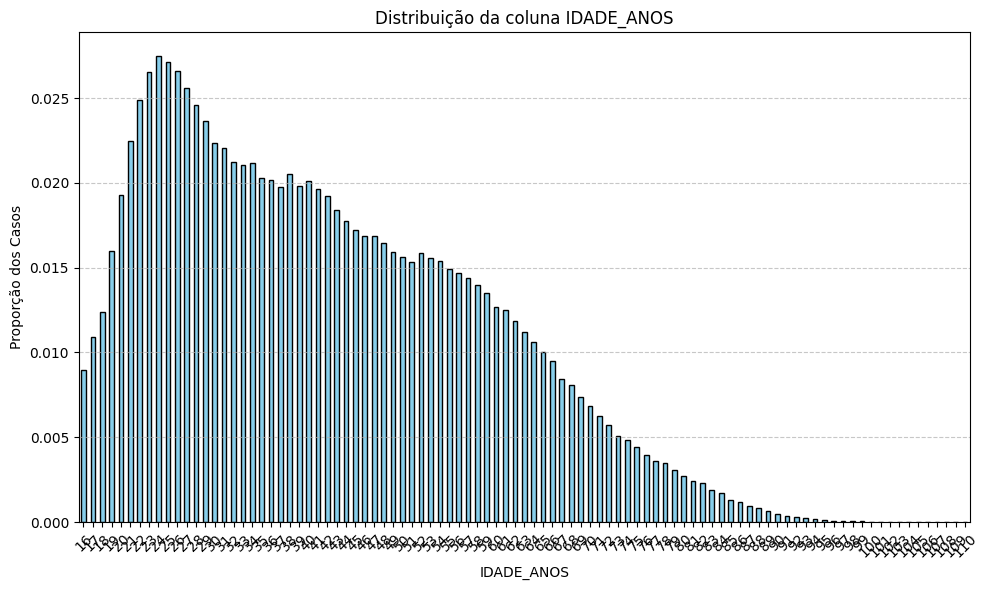

In [113]:
checar_nan(df_cleaned_columns, nome_coluna="IDADE_ANOS")

Vamos dar drop no **ANO_NASC**, pois **IDADE_ANOS** é análogo

In [114]:
df_cleaned_columns = df_cleaned_columns.drop(columns=['ANO_NASC'])

**CS_SEXO**<br><br>
M – Masculino <br>
F – Feminino <br>
I – Ignorado <br> <br>
<br>Sexo do paciente 


A coluna 'CS_SEXO' não contém valores NaN.


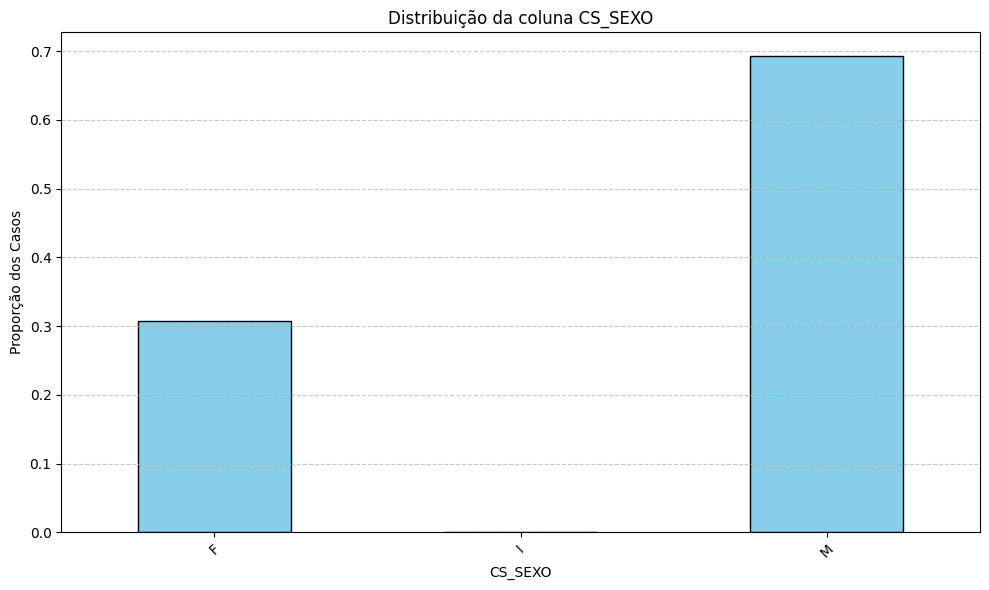

In [115]:
checar_nan(df_cleaned_columns, nome_coluna="CS_SEXO")

Vamos remover apenas os índices indeteminados (I)

In [116]:
df_cleaned_columns = df_cleaned_columns[df_cleaned_columns["CS_SEXO"] != "I"]

**CS_GESTANT** <br> 
Gestante <br> <br> 
1 – 1º Trimestre <br> 
2 – 2º Trimestre <br> 
3 – 3º Trimestre <br> 
4 – Idade gestacional ignorada <br> 
5 – Não <br> 
6 – Não se aplica <br> 
9 – Ignorado <br> <br> 
Idade gestacional da paciente.

Atenção: A coluna 'CS_GESTANT' contém 47996 valores NaN.
Isso representa 15.59% do total de 307820 registros.


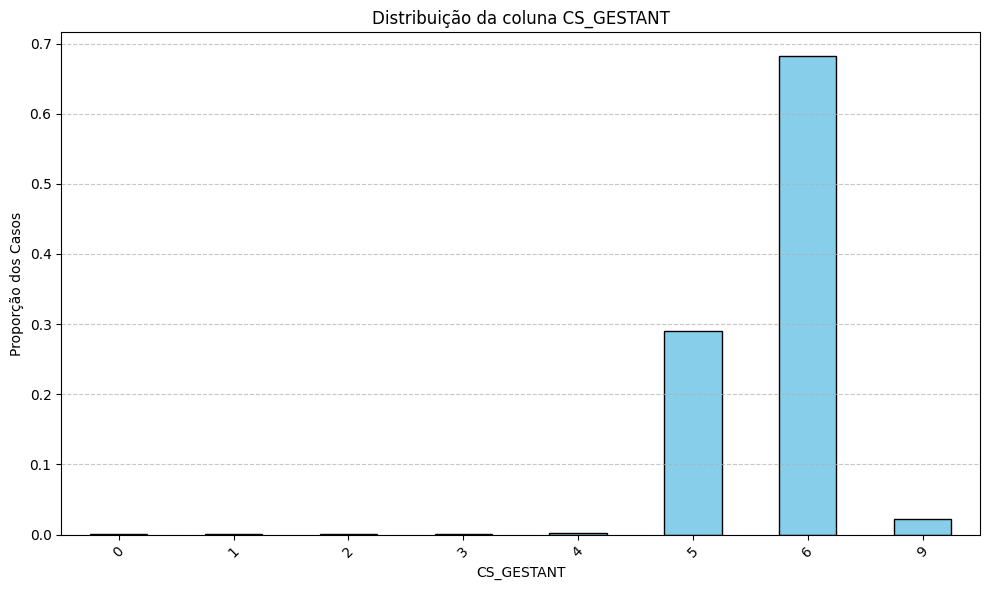

In [117]:
checar_nan(df_cleaned_columns, nome_coluna="CS_GESTANT")

Vamos remover **CS_GESTANT**, pois claramente não há casos positivos para gravidez o suficiente (quase 100% são Não, não se aplica ou Ignorado)

In [118]:
df_cleaned_columns = df_cleaned_columns.drop(columns=['CS_GESTANT'])

**CS_RACA**<br>
Raça/Cor <br>
1 – Branca <br> 
2 – Preta <br>
3 – Amarela <br>
4 – Parda <br>
5 – Indígena <br>
9 – Ignorado <br> <br>

Atenção: A coluna 'CS_RACA' contém 14223 valores NaN.
Isso representa 4.62% do total de 307816 registros.


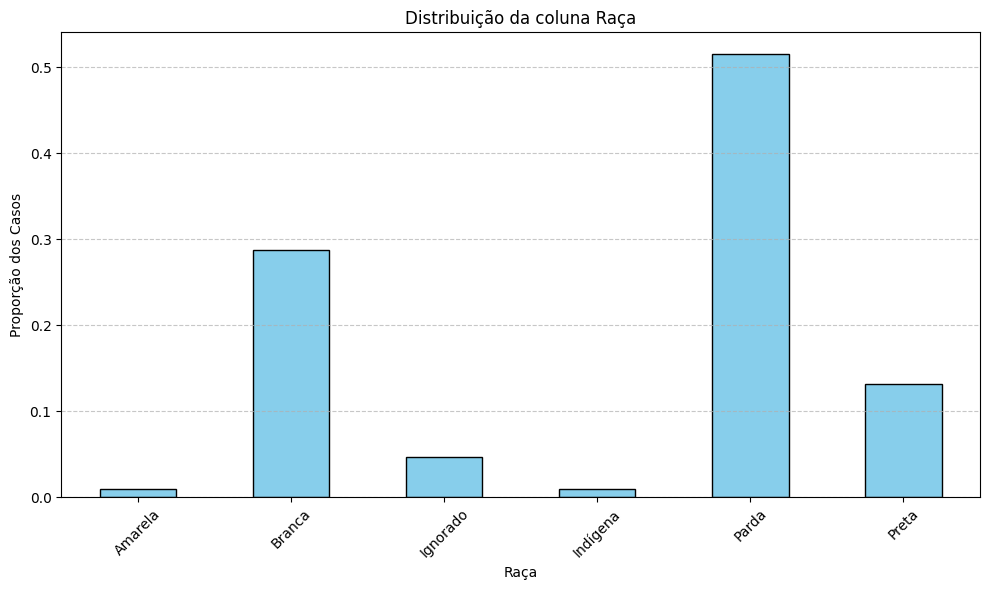

In [119]:
df_cleaned_columns["CS_RACA"] = pd.to_numeric(df_cleaned_columns["CS_RACA"], errors="coerce")

df_cleaned_columns = df_cleaned_columns[~df_cleaned_columns["CS_RACA"].isin([0,6])]
df_cleaned_columns["CS_RACA"].value_counts()
checar_nan(df_cleaned_columns, "CS_RACA", labelnames=["Parda", "Branca", "Preta", "Ignorado", "Indígena", "Amarela"], nome_coluna_renomeado="Raça")

Em **CS_RACA** vamos selecionar apenas casos de pessoas brancas, pretas e pardas, por serem maiores que 10% do total.

In [120]:
df_cleaned_columns["CS_RACA"].value_counts()

CS_RACA
4.0    151168
1.0     84460
2.0     38781
9.0     13669
5.0      2800
3.0      2715
Name: count, dtype: int64

In [121]:
df_cleaned_columns["CS_RACA"] = pd.to_numeric(df_cleaned_columns["CS_RACA"], errors="coerce")
df_cleaned_columns = df_cleaned_columns[df_cleaned_columns["CS_RACA"].isin([1, 2, 4])]
df_cleaned_columns['CS_RACA'] = df_cleaned_columns['CS_RACA'].astype(int)

A coluna 'CS_RACA' não contém valores NaN.


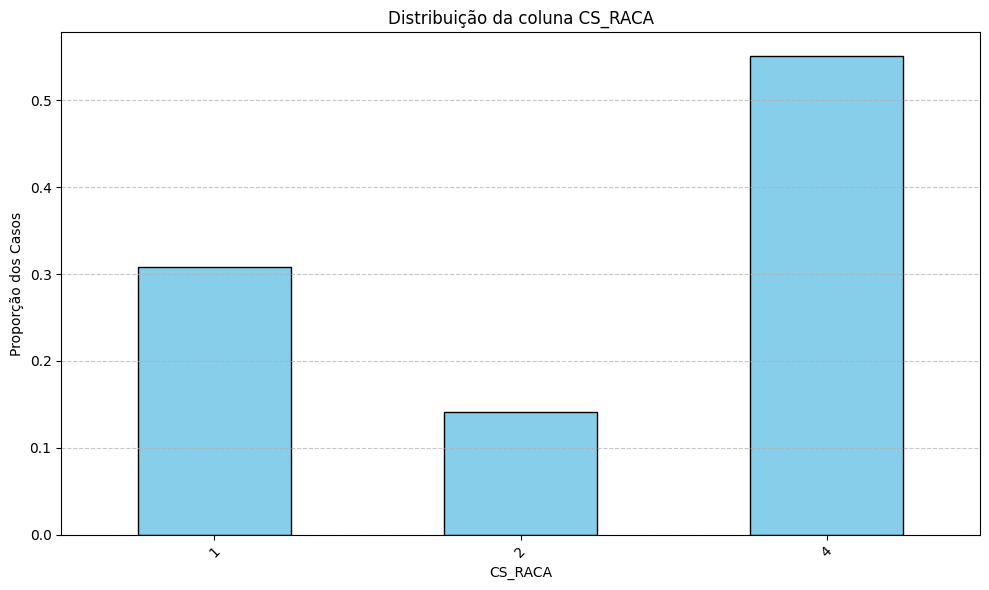

In [122]:
checar_nan(df_cleaned_columns, "CS_RACA")

**ID_PAIS**<br>País (se residente fora do Brasil)<br>Tabela com código e descrição de paises.  País onde residia o paciente por ocasião 
da notificação

In [123]:
df_cleaned_columns["ID_PAIS"].value_counts()

ID_PAIS
1    213195
0        36
7         2
6         2
Name: count, dtype: int64

Vamos remover **ID_PAIS**, visto que não há valores relevantes

In [124]:
df_cleaned_columns = df_cleaned_columns.drop(columns=['ID_PAIS'])

**CS_ESCOL_N**<br>
Escolaridade 
<br><br>
0 – Analfabeto  <br>
1 – 1ª a 4ª série incompleta do EF <br>
2 – 4ª série completa do EF (antigo 1° grau) <br>
3 – 5ª à 8ª série incompleta do EF (antigo ginásio ou 1° grau) <br>
4 – Ensino fundamental completo (antigo ginásio ou 1° grau) <br>
5 – Ensino médio incompleto (antigo colegial ou 2° grau) <br>
6 – Ensino médio completo (antigo colegial ou 2° grau) <br>
7 – Educação superior incompleta  <br>
8 – Educação superior completa  <br>
9 – Ignorado <br>
10 – Não se aplica <br><br>
Série e grau que a pessoa está 
frequentando ou frequentou 
considerando a última série concluída 
com aprovação ou grau de instrução do 
paciente por ocasião da notificação. 


Atenção: A coluna 'CS_ESCOL_N' contém 18208 valores NaN.
Isso representa 6.64% do total de 274409 registros.


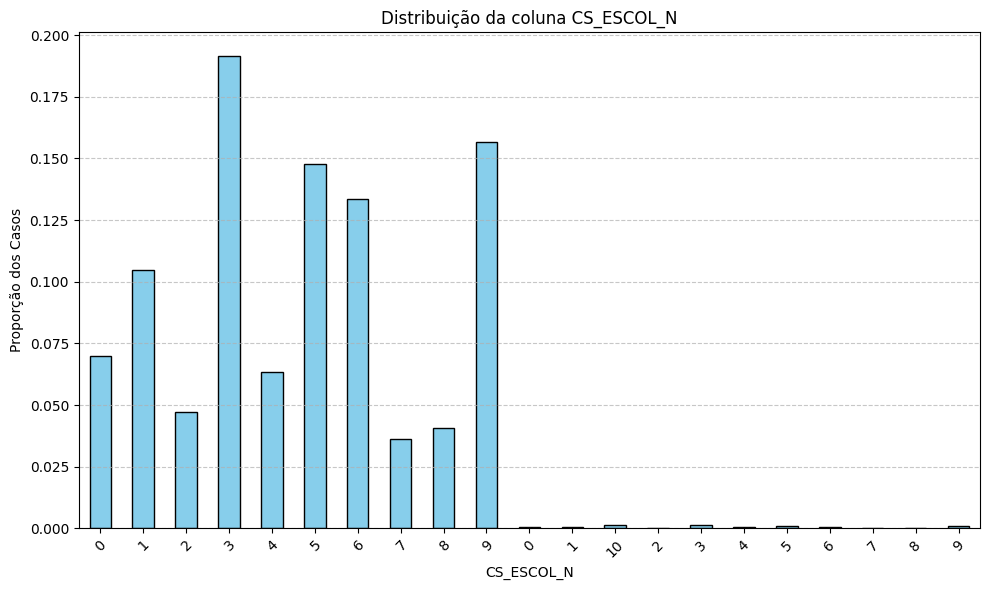

In [125]:
checar_nan(df_cleaned_columns, "CS_ESCOL_N")

Vamos fazer a separação em: <br><br>

1. Esino básico incompleto <br>
2. Ensino básico completo  <br>
3. Ensino médio completo <br>
4. Ensino superior completo <br>

In [126]:
# 1. Converte para numérico e trata erros
df_cleaned_columns["CS_ESCOL_N"] = pd.to_numeric(df_cleaned_columns["CS_ESCOL_N"], errors="coerce")

# 2. Filtra apenas os valores válidos (os que têm uma categoria definida)
df_cleaned_columns = df_cleaned_columns[df_cleaned_columns["CS_ESCOL_N"].isin([0, 1, 2, 3, 4, 6, 8])]

# 3. Agora sim, aplica a categorização
def categorizar_escolaridade(valor):
    if valor in [0, 1, 2, 3]:
        return 0
    elif valor == 4:
        return 1
    elif valor == 6:
        return 2
    elif valor == 8:
        return 3

df_cleaned_columns["ESCOL_CATEGORIZADA"] = df_cleaned_columns["CS_ESCOL_N"].apply(categorizar_escolaridade)


A coluna 'ESCOL_CATEGORIZADA' não contém valores NaN.


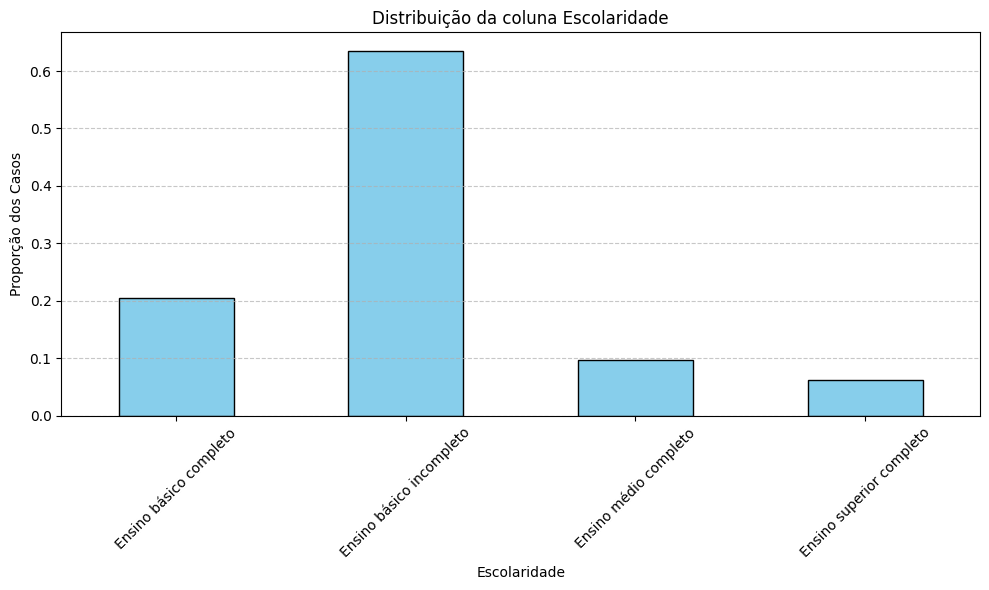

In [127]:
checar_nan(df_cleaned_columns, "ESCOL_CATEGORIZADA", labelnames=["Ensino básico incompleto", "Ensino básico completo", "Ensino médio completo", "Ensino superior completo"], nome_coluna_renomeado="Escolaridade")

In [128]:
df_cleaned_columns = df_cleaned_columns.drop(columns=['CS_ESCOL_N'])

**TRATAMENTO** <br>
<br>Preencher com o 
código 
correspondente ao 
tipo de entrada do 
paciente na unidade 
de saúde. O “caso 
novo” é todo paciente 
que nunca se 
submeteu ao 
tratamento de tuberculose, ou o fez 
por até 30 dias. Os 
retratamentos podem 
acontecer por: 
“recidiva” após cura e 
“reingresso após 
abandono”, quando 
ocorre interrupção de 
um tratamento por 
mais de 30 dias. O 
“Não sabe” deve ser 
preenchido apenas 
quando esgotadas as 
possibilidades de 
investigação das 
entradas anteriores do 
paciente. A 
“transferência” se 
refere ao paciente 
encaminhado de outro 
serviço para 
seguimento do 
tratamento. Os casos 
com entrada “Pós-
óbito” são aqueles 
identificados 
tardiamente, ou seja, 
no momento ou após 
a morte do paciente<br>
1. Caso Novo <br>
2. Recidiva <br>
3. Reingresso após Abandono <br>
4. Não Sabe <br>
5. Transferência <br>
6. Pós-óbito

A coluna 'TRATAMENTO' não contém valores NaN.


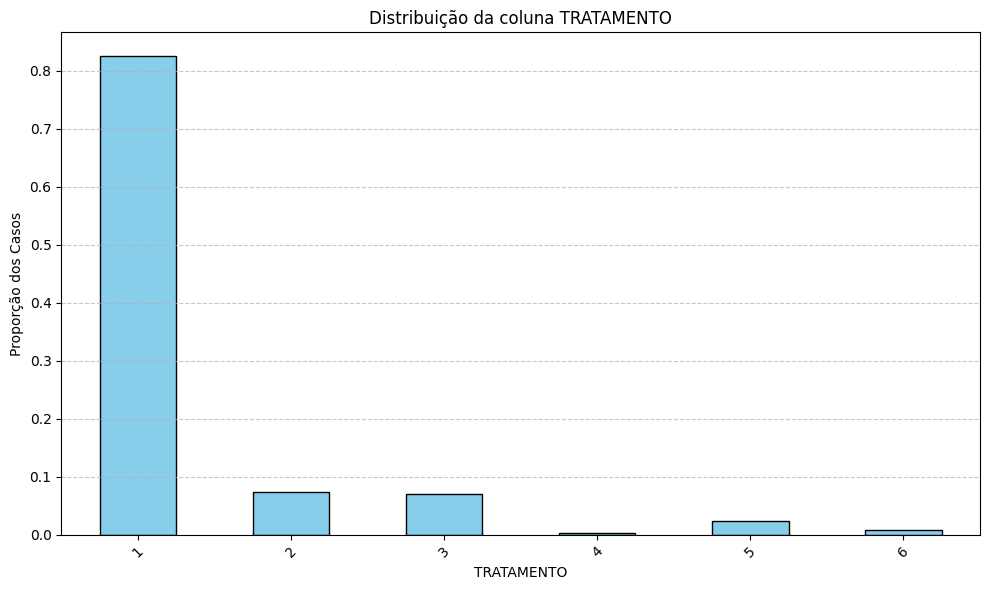

In [129]:
checar_nan(df_cleaned_columns, "TRATAMENTO")

Como as informações da coluna 'TRATAMENTO' não estão disponíveis no momento da notificação, não podemos usar essa coluna na inferência e nem no treinamento.

In [130]:
df_cleaned_columns = df_cleaned_columns.drop(columns=['TRATAMENTO'])

**FORMA** <br>
1. Pulmonar <br>
2. Extrapulmonar <br>
3. Pulmonar + Extrapulmonar

A coluna 'FORMA' não contém valores NaN.


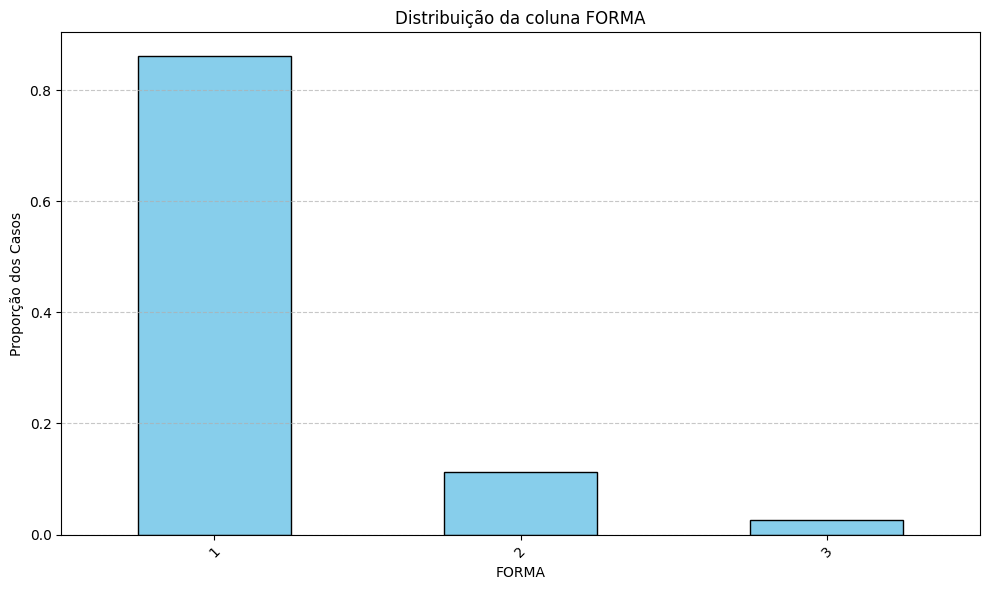

In [131]:
checar_nan(df_cleaned_columns, "FORMA")

Vamos remover apenas a classe 3, que tem apenas de 5%

In [132]:
df_cleaned_columns["FORMA"] = pd.to_numeric(df_cleaned_columns["FORMA"], errors="coerce")

df_cleaned_columns = df_cleaned_columns[df_cleaned_columns["FORMA"].isin([1, 2])]

In [133]:
df_cleaned_columns.columns

Index(['Unnamed: 0', 'DT_NOTIFIC', 'NU_ANO', 'DT_DIAG', 'CS_SEXO', 'CS_RACA',
       'ID_MN_RESI', 'ID_RG_RESI', 'DT_DIGITA', 'FORMA', 'EXTRAPU1_N',
       'AGRAVAIDS', 'AGRAVALCOO', 'AGRAVDIABE', 'AGRAVDOENC', 'AGRAVOUTRA',
       'DT_INIC_TR', 'NU_CONTATO', 'SG_UF_AT', 'DT_NOTI_AT', 'SG_UF_2',
       'TRATSUP_AT', 'NU_COMU_EX', 'DT_ENCERRA', 'TPUNINOT', 'POP_LIBER',
       'POP_RUA', 'POP_SAUDE', 'POP_IMIG', 'BENEF_GOV', 'AGRAVDROGA',
       'AGRAVTABAC', 'arquivo', 'SITUACAO_AGRUPADA', 'REGIAO', 'IDADE_ANOS',
       'ESCOL_CATEGORIZADA'],
      dtype='object')

**NU_COMU_EX**<br> 
Total de contatos <br> 
Preencher o total de 
Contatos identificados 
pelo paciente na 
ocasião do diagnóstico 
do caso. <br> 
Campo Obrigatório 

Atenção: A coluna 'NU_COMU_EX' contém 15536 valores NaN.
Isso representa 9.50% do total de 163553 registros.


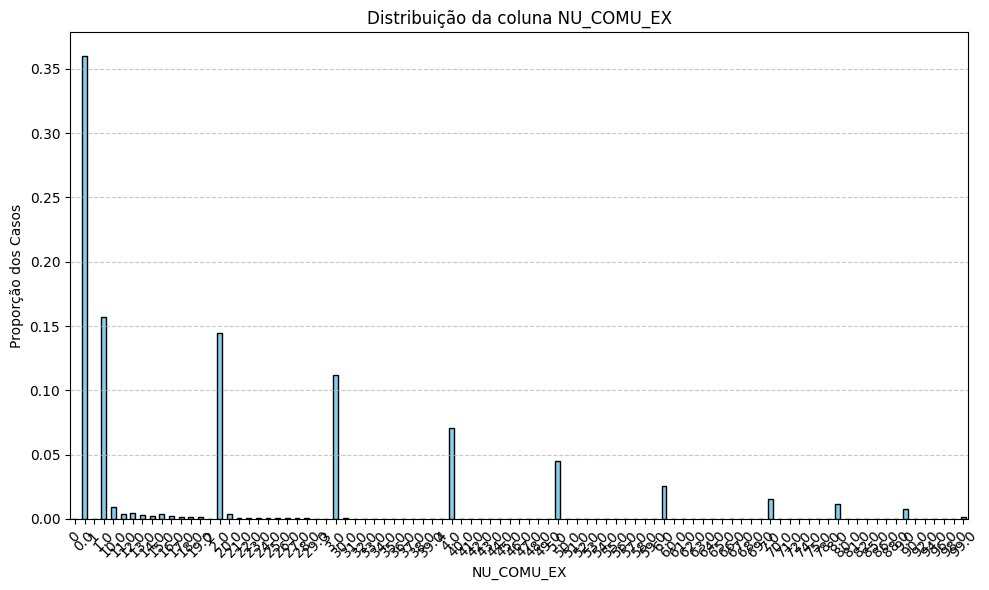

In [134]:
checar_nan(df_cleaned_columns, "NU_COMU_EX")

In [135]:
df_cleaned_columns["NU_COMU_EX"] = pd.to_numeric(df_cleaned_columns["NU_COMU_EX"], errors="coerce").dropna().astype(int)

**AGRAVOS**<br>
AGRAVOS (AGRAVAIDS, AGRAVALCOO, AGRAVDIABE, AGRAVDOENC, AGRAVOUTRA) varchar2(1) <br>
1. Sim <br>
2. Não <br>
9. Ignorado

Atenção: A coluna 'AGRAVAIDS' contém 1983 valores NaN.
Isso representa 1.21% do total de 163553 registros.


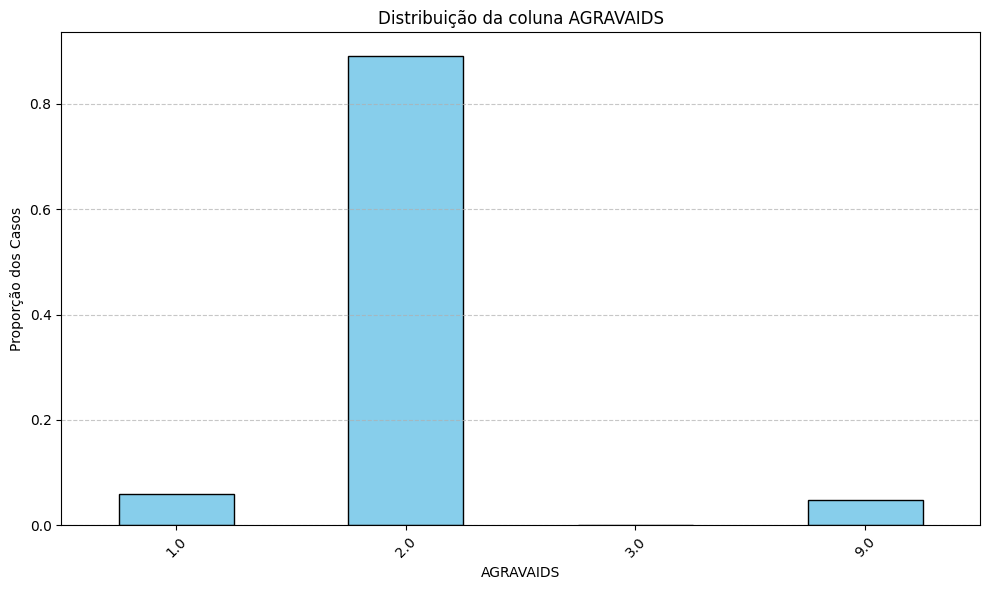

Atenção: A coluna 'AGRAVALCOO' contém 1449 valores NaN.
Isso representa 0.89% do total de 163553 registros.


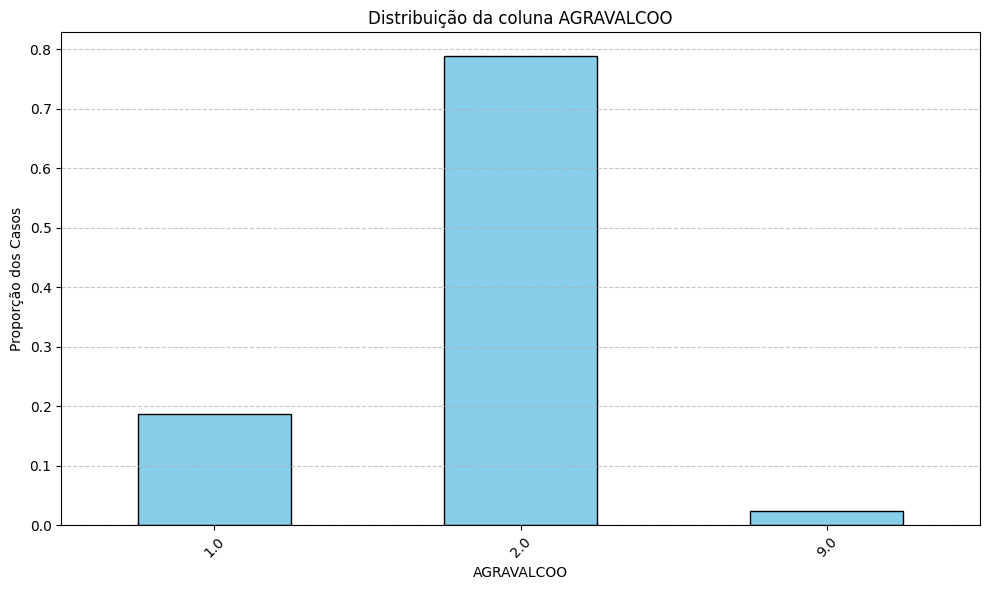

Atenção: A coluna 'AGRAVDIABE' contém 1504 valores NaN.
Isso representa 0.92% do total de 163553 registros.


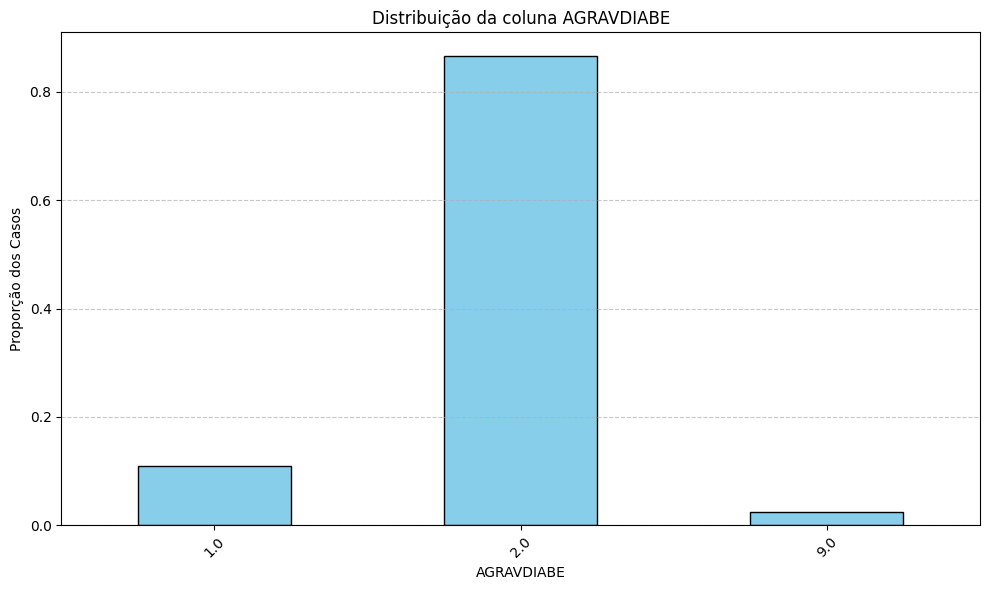

Atenção: A coluna 'AGRAVDOENC' contém 1932 valores NaN.
Isso representa 1.18% do total de 163553 registros.


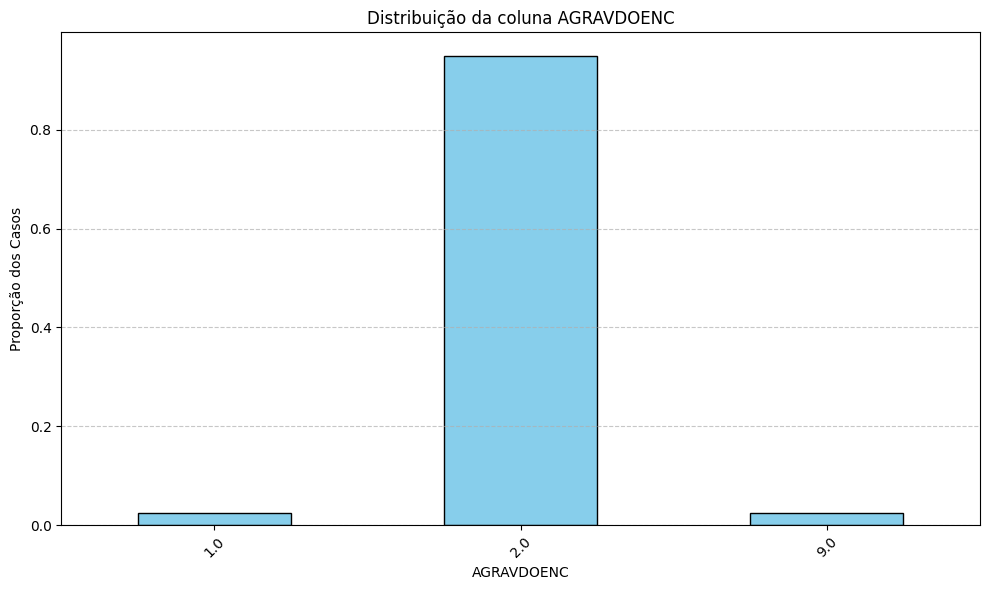

Atenção: A coluna 'AGRAVOUTRA' contém 46519 valores NaN.
Isso representa 28.44% do total de 163553 registros.


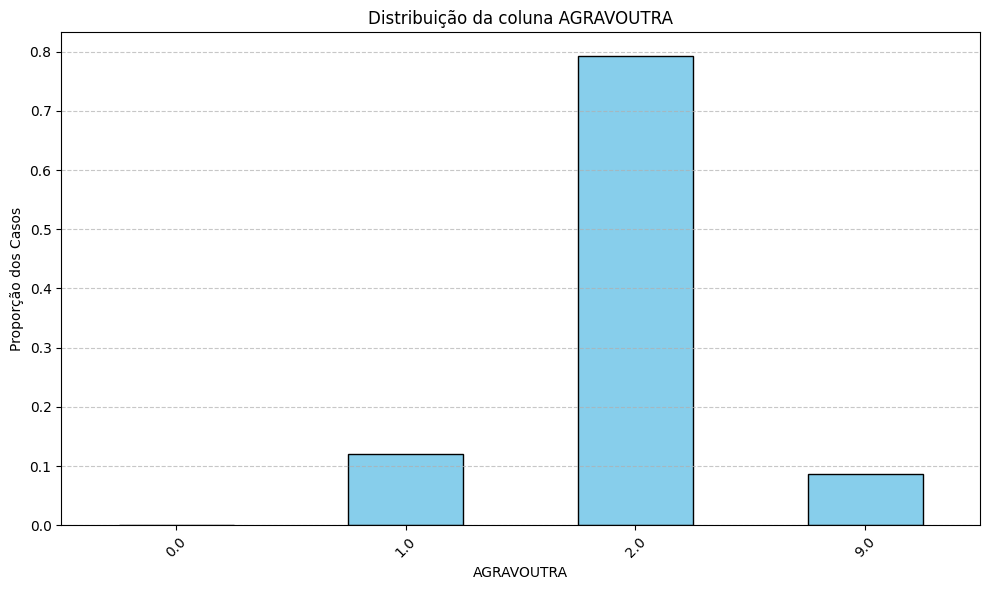

In [136]:
# Lista das colunas a serem removidas
colunas_separadas = [
    'AGRAVAIDS', 'AGRAVALCOO', 'AGRAVDIABE', 'AGRAVDOENC', 'AGRAVOUTRA'
]

for coluna in colunas_separadas:
    df_cleaned_columns[coluna] = pd.to_numeric(df_cleaned_columns[coluna], errors="coerce")
    checar_nan(df_cleaned_columns, nome_coluna=coluna)

Decidimos remover as anotações que foram colocadas em ignorado, e remover a coluna de **AGRAVOENC**

A coluna 'AGRAVAIDS' não contém valores NaN.


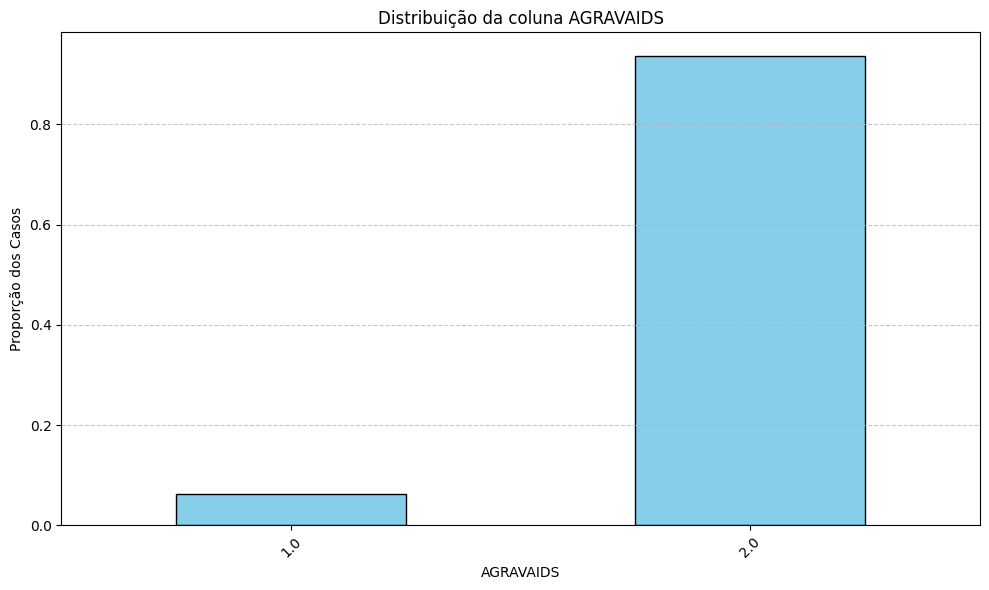

A coluna 'AGRAVALCOO' não contém valores NaN.


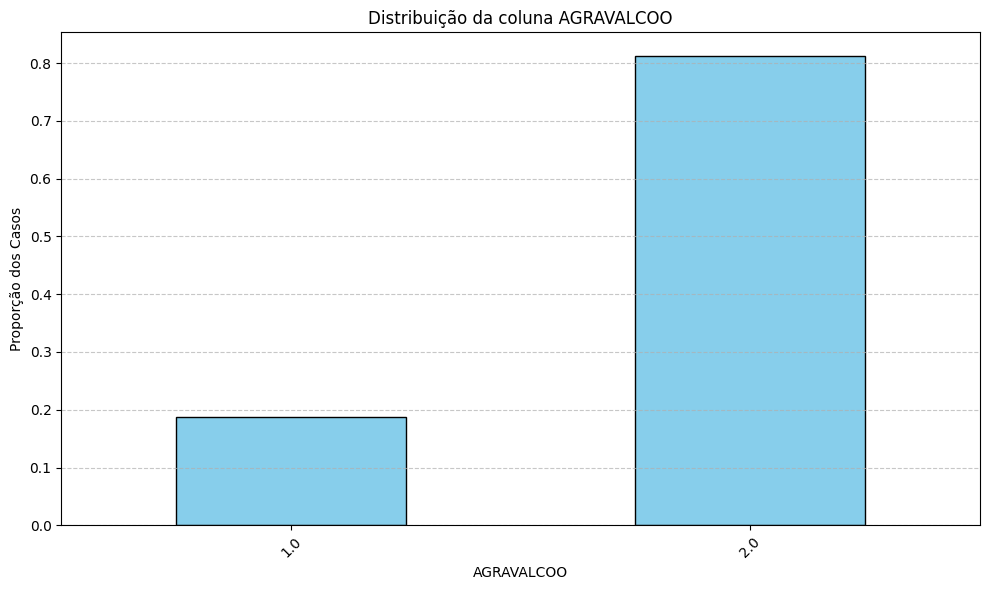

A coluna 'AGRAVDIABE' não contém valores NaN.


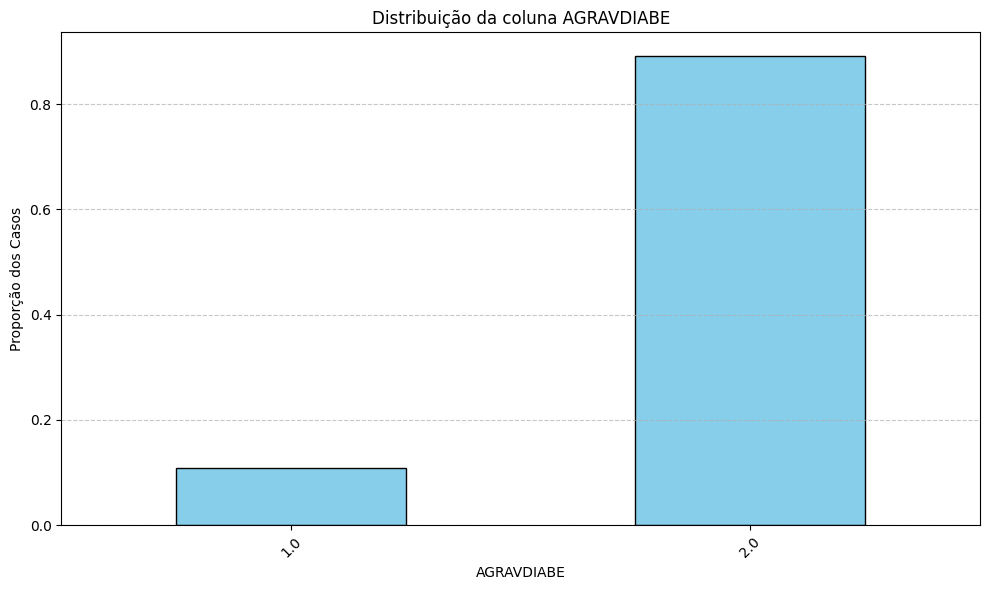

A coluna 'AGRAVDOENC' não contém valores NaN.


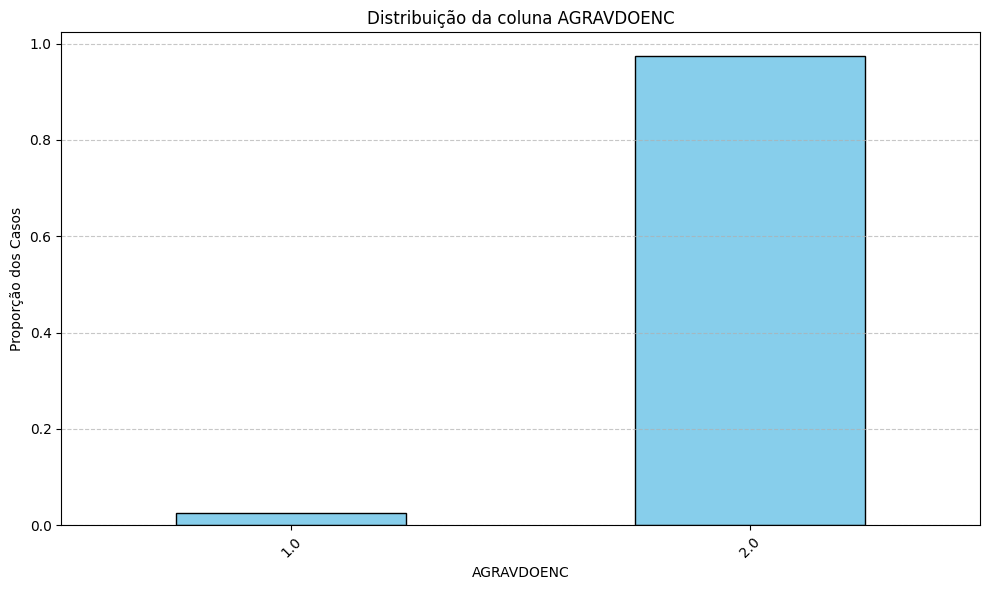

A coluna 'AGRAVOUTRA' não contém valores NaN.


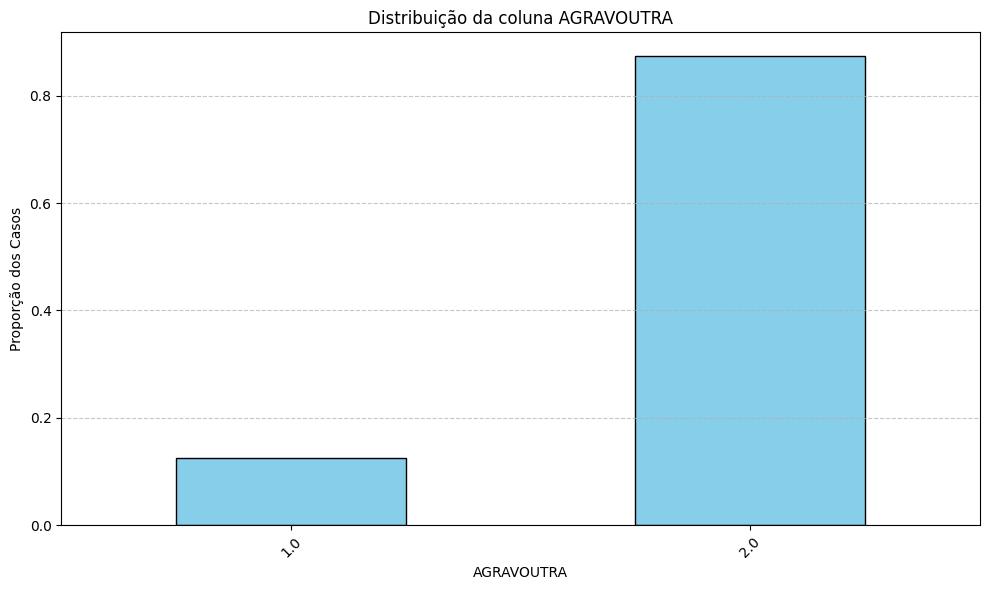

In [137]:
for coluna in colunas_separadas:
    df_cleaned_columns = df_cleaned_columns[df_cleaned_columns[coluna].isin([1, 2])]
    checar_nan(df_cleaned_columns, nome_coluna=coluna)

df_cleaned_columns = df_cleaned_columns.drop(columns=['AGRAVDOENC'])

**TRATSUP_AT**<br>
Tratamento Diretamente Observado (TDO) realizado - varchar2(1): <br>
1- Sim <br>
2- Não <br>
9- Ignorado <br>

Atenção: A coluna 'TRATSUP_AT' contém 18005 valores NaN.
Isso representa 17.75% do total de 101456 registros.


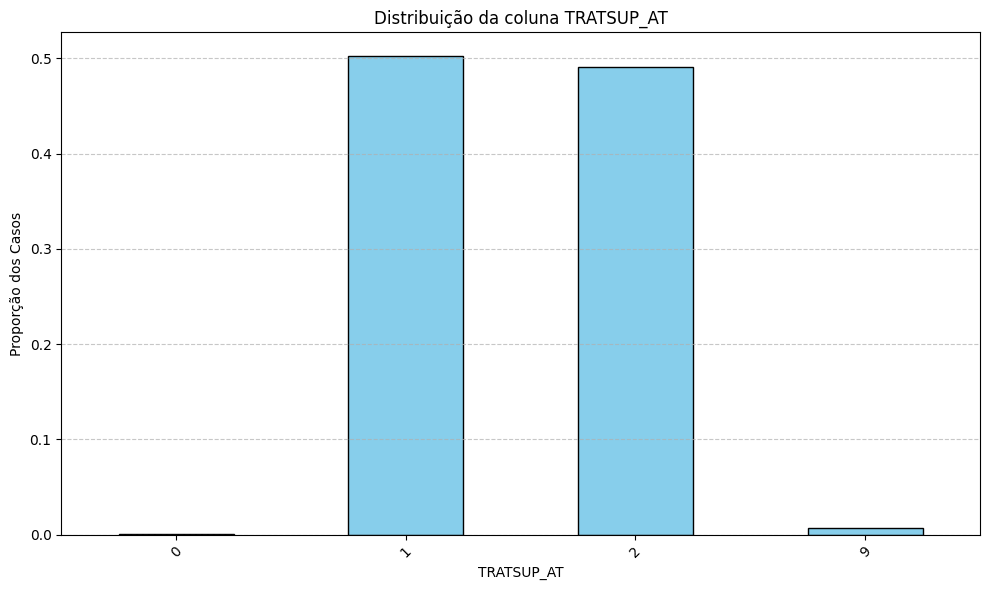

In [138]:
checar_nan(df_cleaned_columns, "TRATSUP_AT")

Vamos pegar apenas os casos de sim e não.

In [139]:
df_cleaned_columns["TRATSUP_AT"] = pd.to_numeric(df_cleaned_columns["TRATSUP_AT"], errors="coerce")
df_cleaned_columns = df_cleaned_columns[df_cleaned_columns["TRATSUP_AT"].isin([1, 2])]

In [140]:
df_cleaned_columns.columns

Index(['Unnamed: 0', 'DT_NOTIFIC', 'NU_ANO', 'DT_DIAG', 'CS_SEXO', 'CS_RACA',
       'ID_MN_RESI', 'ID_RG_RESI', 'DT_DIGITA', 'FORMA', 'EXTRAPU1_N',
       'AGRAVAIDS', 'AGRAVALCOO', 'AGRAVDIABE', 'AGRAVOUTRA', 'DT_INIC_TR',
       'NU_CONTATO', 'SG_UF_AT', 'DT_NOTI_AT', 'SG_UF_2', 'TRATSUP_AT',
       'NU_COMU_EX', 'DT_ENCERRA', 'TPUNINOT', 'POP_LIBER', 'POP_RUA',
       'POP_SAUDE', 'POP_IMIG', 'BENEF_GOV', 'AGRAVDROGA', 'AGRAVTABAC',
       'arquivo', 'SITUACAO_AGRUPADA', 'REGIAO', 'IDADE_ANOS',
       'ESCOL_CATEGORIZADA'],
      dtype='object')

Agora, vamos olhar as colunas que faltam que tenham muitos termos diferentes para a mesma coluna

Sobraram três variáveis de datas relevantes:<br> <br>
**DT_DIAG:** Data da notificação ao profissional da saúde<br>
**DT_NOTIFIC:** Data da Notificação Atual <br>
**DT_INIC_TR:** Data de inicio de tratamento <br>
**DT_ENCERRA:** Data de encerramento<br><br>
**DT_DIGITA:** SEM DOCUMENTAÇÃO

Vamos apagar **DT_DIGITA**, por não ter informações sobre

In [141]:
df_cleaned_columns = df_cleaned_columns.drop(columns=['DT_DIGITA'])

Agora vamos apagar as únicas variáveis de de datas que sobraram e transformar elas em uma variável de faixa de tempo
<br>TEMPO_DE_NOTI: Tempo entre os primeiros sintomas e a notificação

In [142]:
df_cleaned_columns['DT_DIAG'] = pd.to_datetime(df_cleaned_columns['DT_DIAG'], errors='coerce')
df_cleaned_columns['DT_NOTIFIC'] = pd.to_datetime(df_cleaned_columns['DT_NOTIFIC'], errors='coerce')
df_cleaned_columns['DT_INIC_TR'] = pd.to_datetime(df_cleaned_columns['DT_INIC_TR'], errors='coerce')

df_cleaned_columns['TEMPO_DE_NOTI'] = (df_cleaned_columns['DT_NOTIFIC'] - df_cleaned_columns['DT_DIAG']).dt.days
df_cleaned_columns['TEMPO_DE_INICIO_TRATAMENTO'] = (df_cleaned_columns['DT_INIC_TR'] - df_cleaned_columns['DT_DIAG']).dt.days

A coluna 'TEMPO_DE_NOTI' não contém valores NaN.


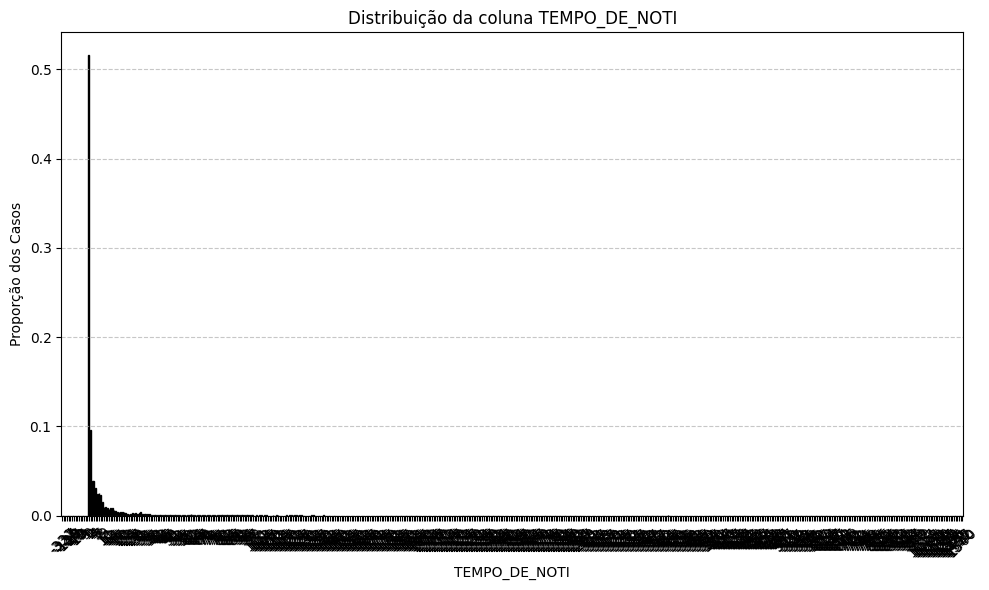

Atenção: A coluna 'TEMPO_DE_INICIO_TRATAMENTO' contém 1386 valores NaN.
Isso representa 1.67% do total de 82833 registros.


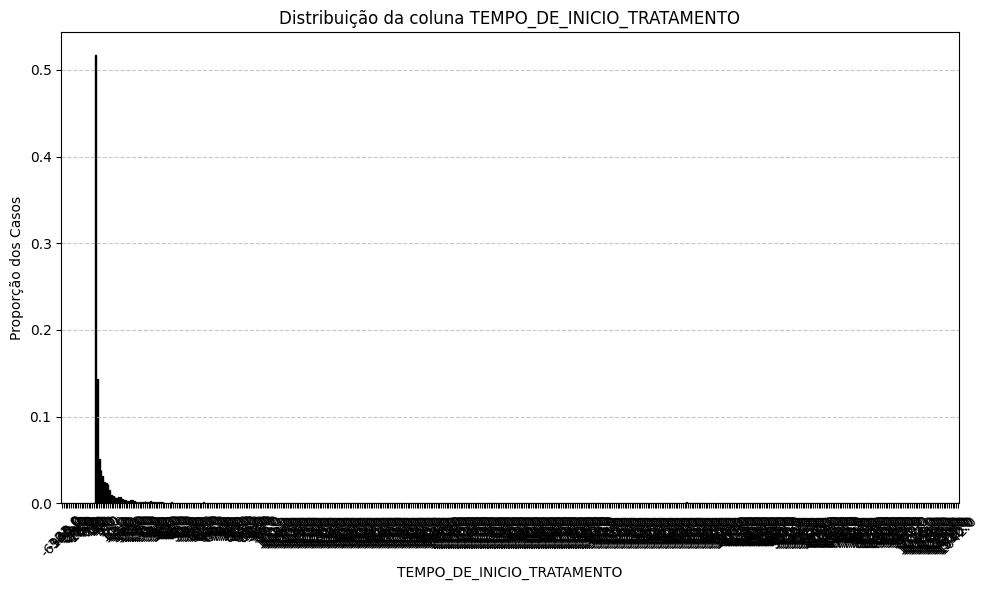

In [143]:
checar_nan(df_cleaned_columns, nome_coluna='TEMPO_DE_NOTI')
checar_nan(df_cleaned_columns, nome_coluna='TEMPO_DE_INICIO_TRATAMENTO')

Aqui apagamos as datas:

In [144]:
df_cleaned_columns = df_cleaned_columns.drop(columns=['DT_DIAG'])
df_cleaned_columns = df_cleaned_columns.drop(columns=['DT_NOTIFIC'])
df_cleaned_columns = df_cleaned_columns.drop(columns=['DT_ENCERRA'])
df_cleaned_columns = df_cleaned_columns.drop(columns=['DT_INIC_TR'])

Vamos remover as seguintes colunas por redundância (existem já colunas equivalentes): **SG_UF_2** **SG_UF_AT** **DT_NOTI_AT**

Atenção: A coluna 'SG_UF_2' contém 491 valores NaN.
Isso representa 0.59% do total de 82833 registros.


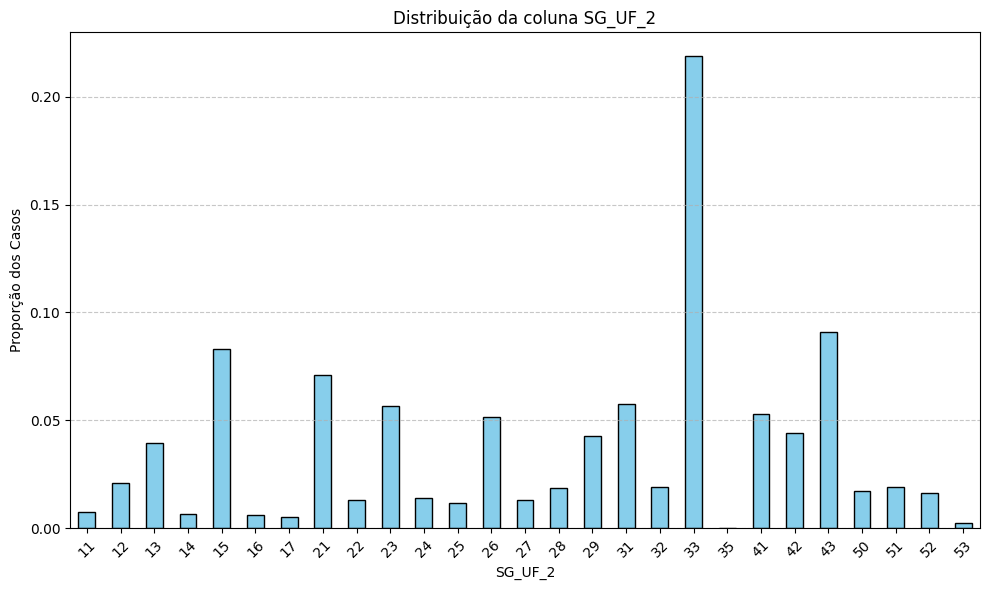

Atenção: A coluna 'SG_UF_AT' contém 83 valores NaN.
Isso representa 0.10% do total de 82833 registros.


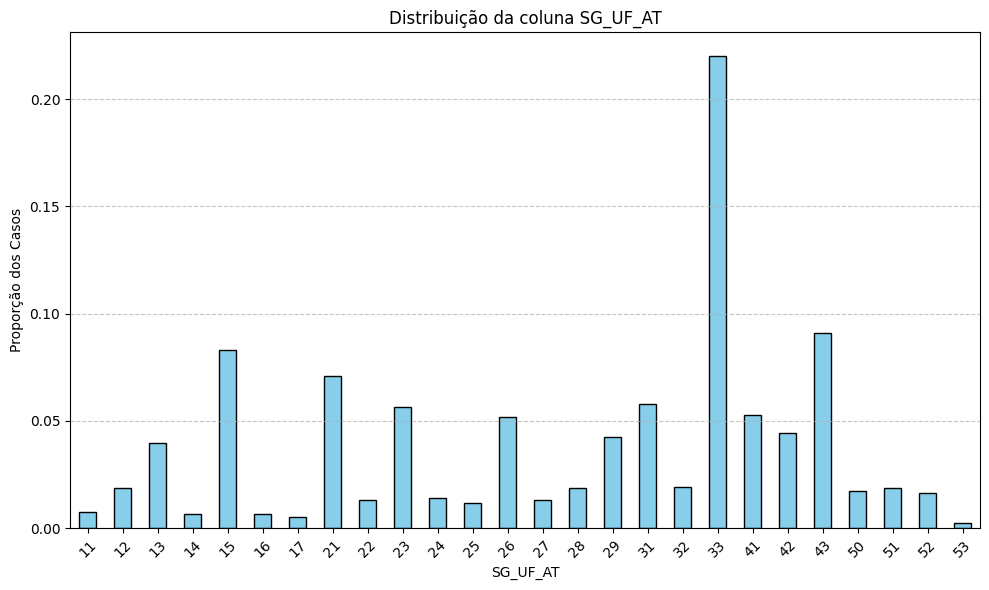

Atenção: A coluna 'DT_NOTI_AT' contém 84 valores NaN.
Isso representa 0.10% do total de 82833 registros.


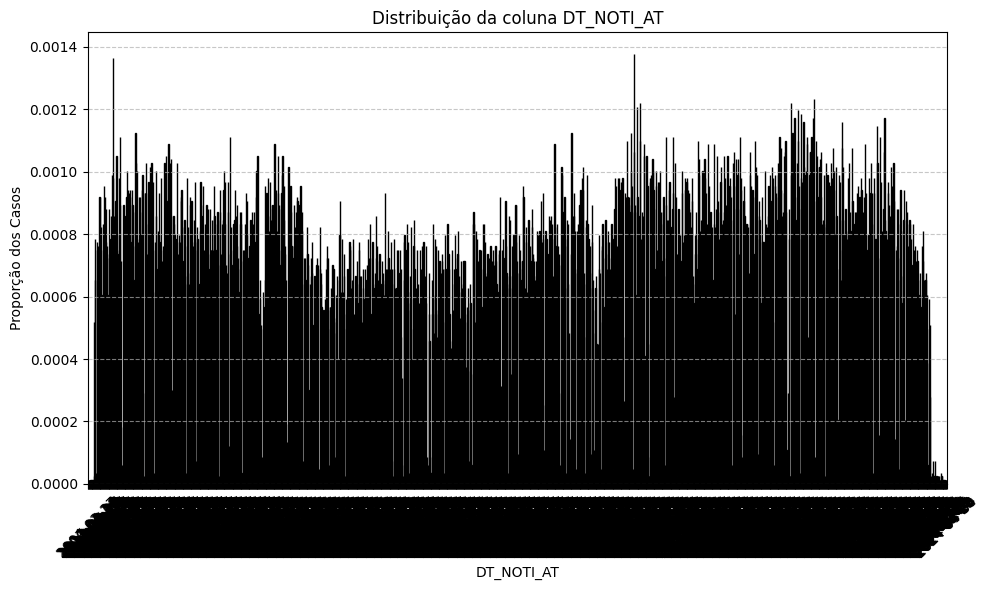

In [145]:
# Lista das colunas a serem removidas
colunas_separadas = [
    'SG_UF_2', 'SG_UF_AT', 'DT_NOTI_AT'
]

for coluna in colunas_separadas:
    checar_nan(df_cleaned_columns, nome_coluna=coluna)
    df_cleaned_columns = df_cleaned_columns.drop(columns=[coluna])
    

Vamos remover as seguintes colunas por não ter documentação ou ser baseado em índices irrelevantes: **ID_RG_RESI** **ID_MN_RESI** **EXTRAPU1_N** **arquivo**, **TPUNINOT**

Atenção: A coluna 'ID_RG_RESI' contém 21904 valores NaN.
Isso representa 26.44% do total de 82833 registros.


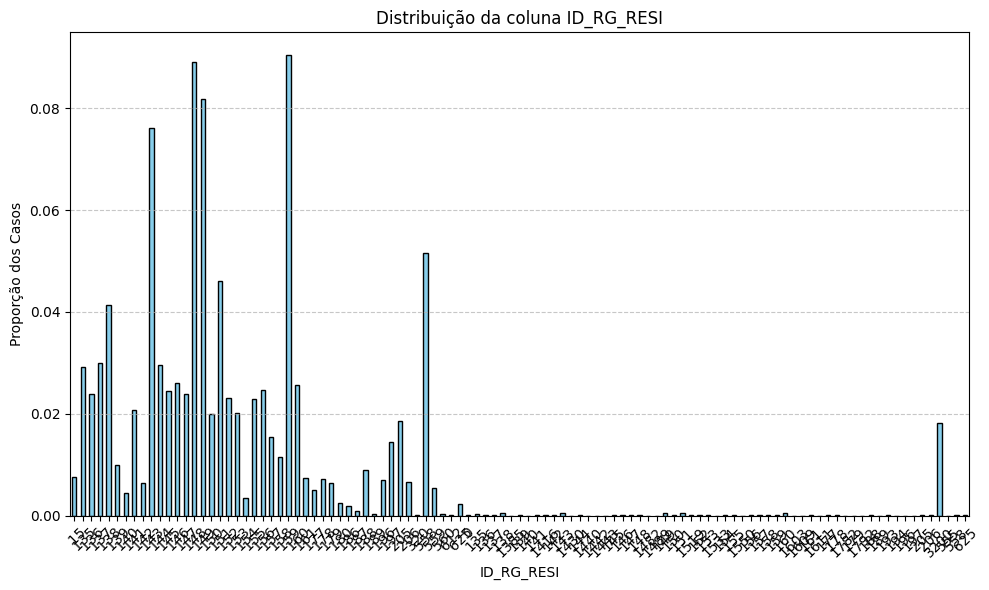

A coluna 'ID_MN_RESI' não contém valores NaN.


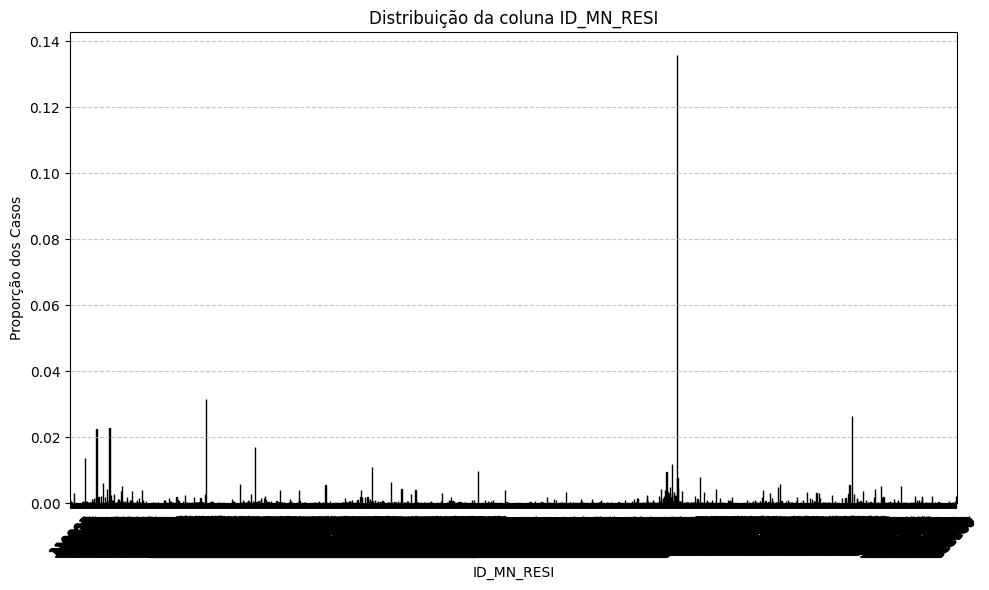

Atenção: A coluna 'EXTRAPU1_N' contém 384 valores NaN.
Isso representa 0.46% do total de 82833 registros.


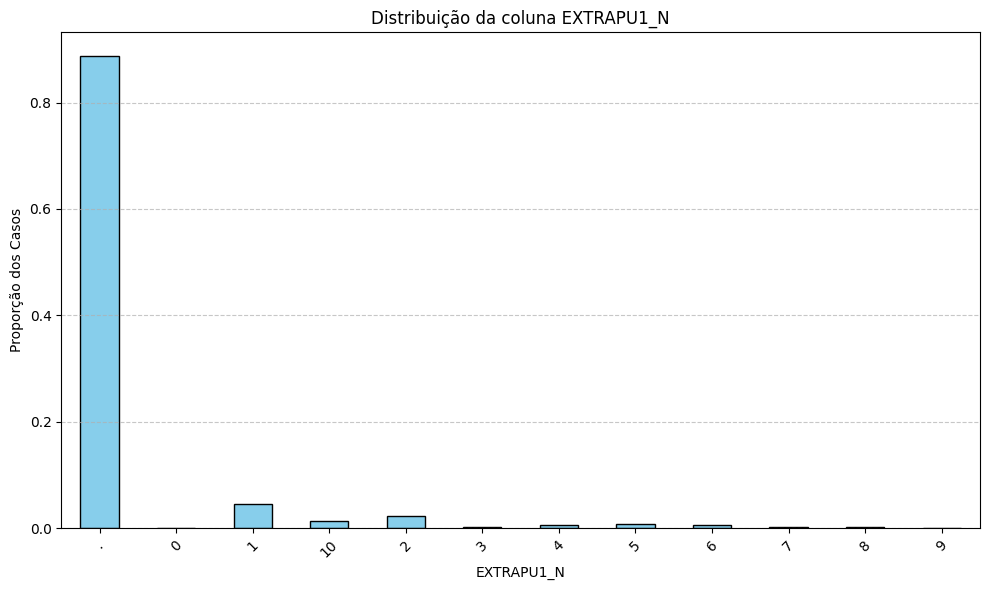

A coluna 'arquivo' não contém valores NaN.


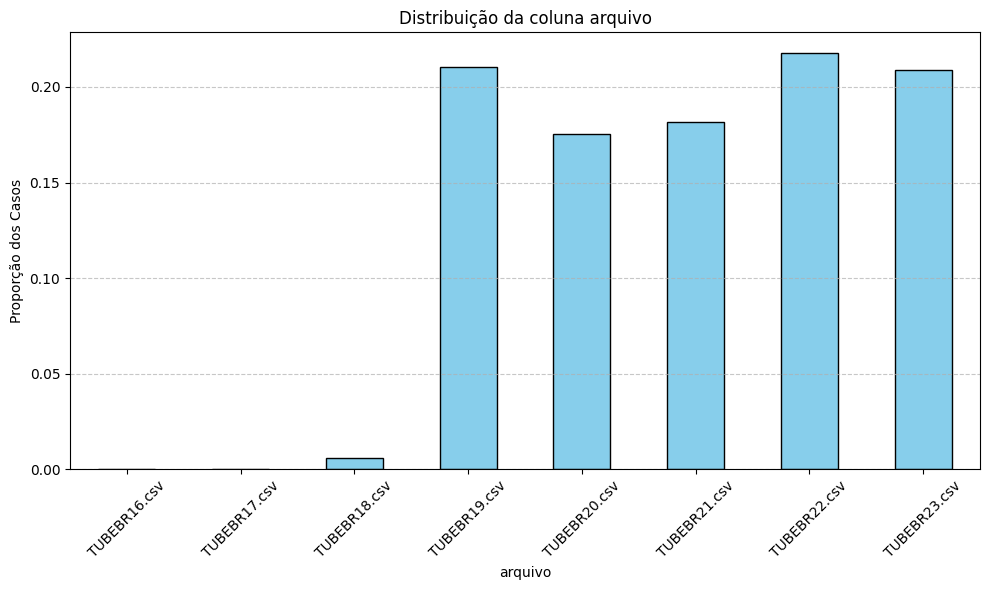

Atenção: A coluna 'TPUNINOT' contém 2917 valores NaN.
Isso representa 3.52% do total de 82833 registros.


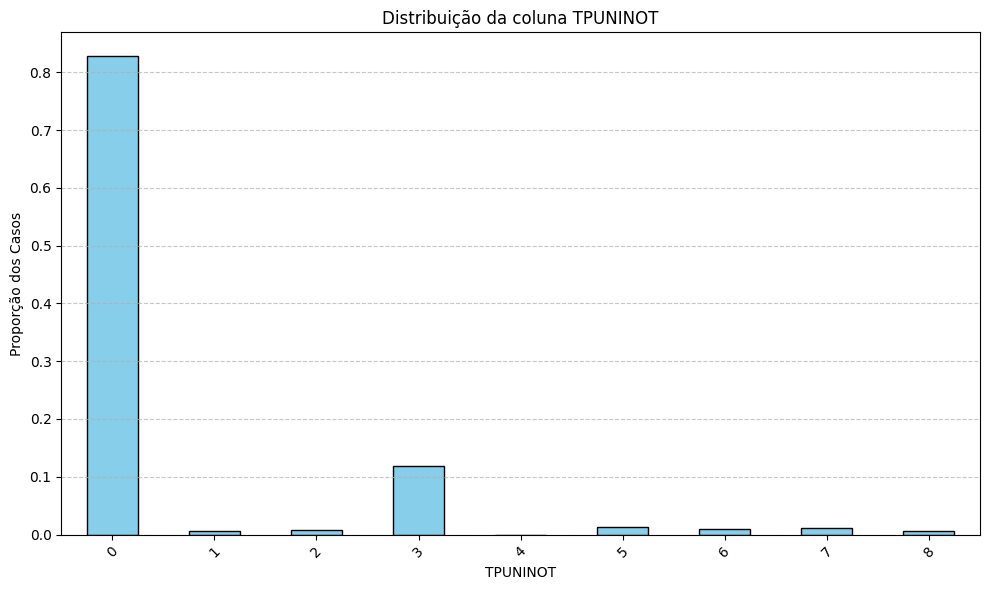

In [146]:
# Lista das colunas a serem removidas
colunas_separadas = [
    'ID_RG_RESI', 'ID_MN_RESI', 'EXTRAPU1_N', 'arquivo', 'TPUNINOT'
]

for coluna in colunas_separadas:
    checar_nan(df_cleaned_columns, nome_coluna=coluna)
    df_cleaned_columns = df_cleaned_columns.drop(columns=[coluna])

**Populações Especiais ('POP_LIBER', 'POP_RUA', 'POP_SAUDE', 'POP_IMIG')**, <br>
 Beneficiários de programas do governo (BENEF_GOV) <br>
 varchar2(1): <br>
1- Sim <br>
2- Não <br>
9- Ignorado

Atenção: A coluna 'POP_LIBER' contém 674 valores NaN.
Isso representa 0.81% do total de 82833 registros.


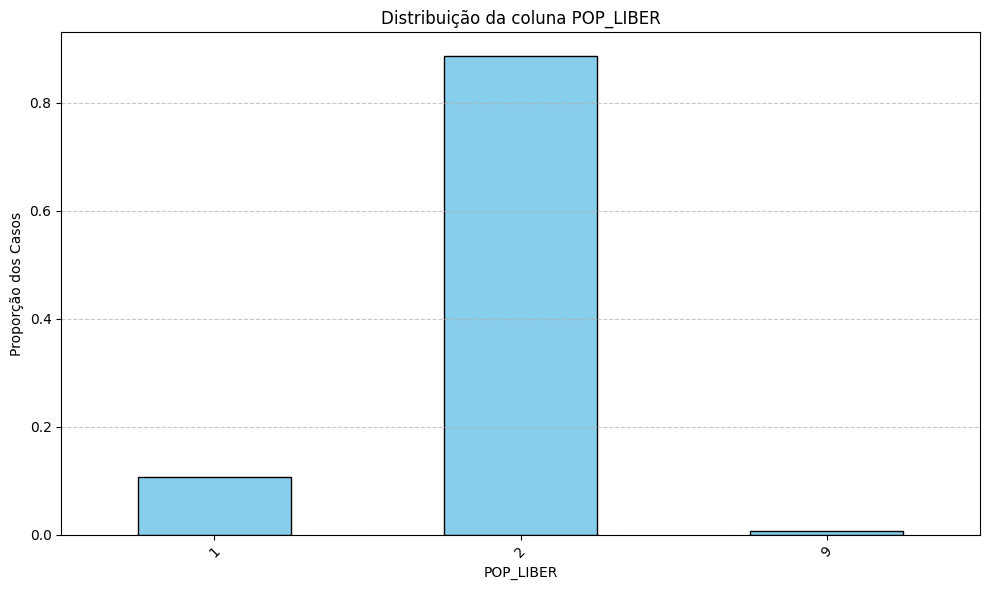

Atenção: A coluna 'POP_RUA' contém 782 valores NaN.
Isso representa 0.94% do total de 82833 registros.


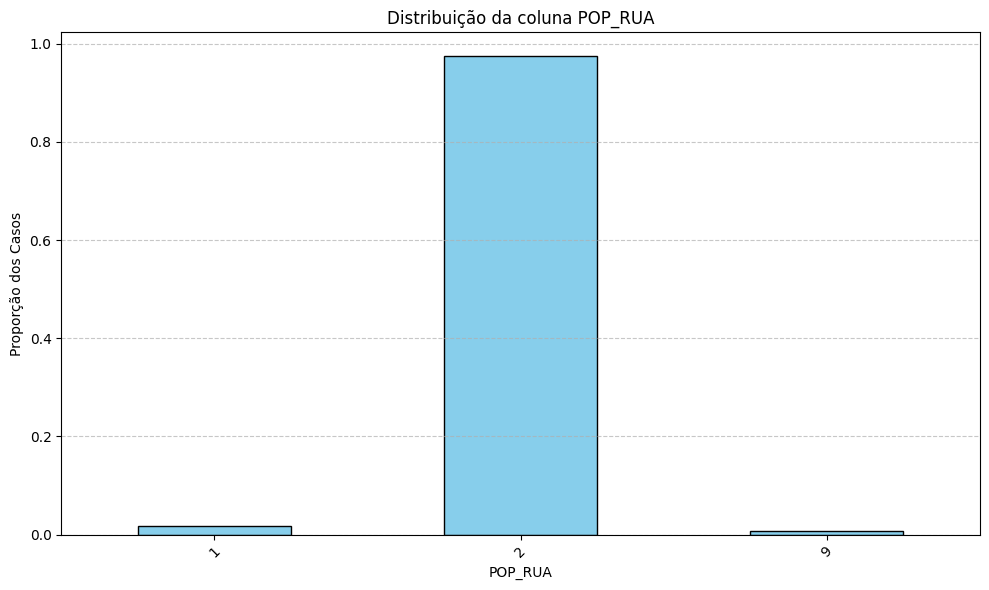

Atenção: A coluna 'POP_SAUDE' contém 759 valores NaN.
Isso representa 0.92% do total de 82833 registros.


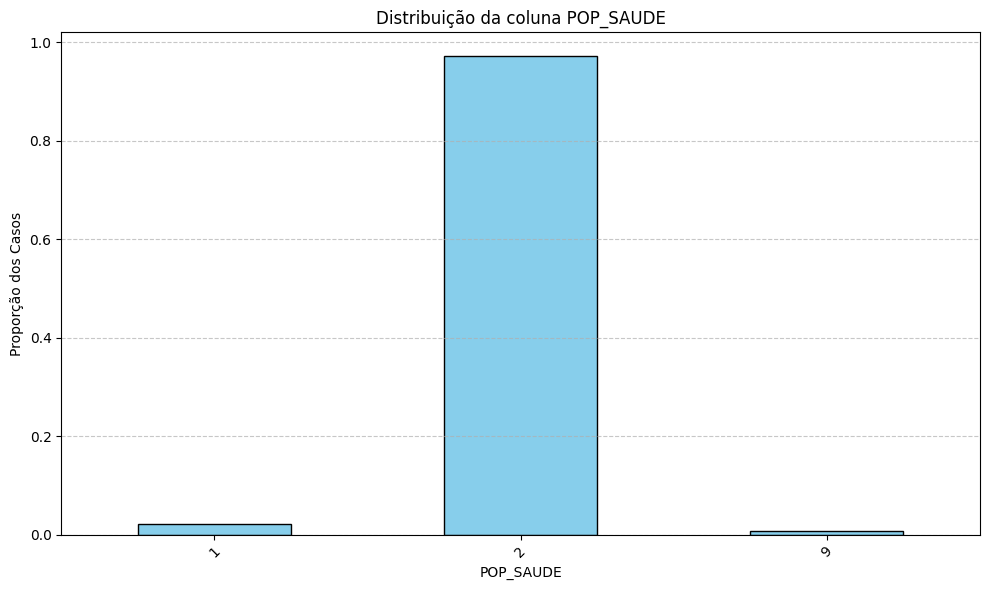

Atenção: A coluna 'POP_IMIG' contém 806 valores NaN.
Isso representa 0.97% do total de 82833 registros.


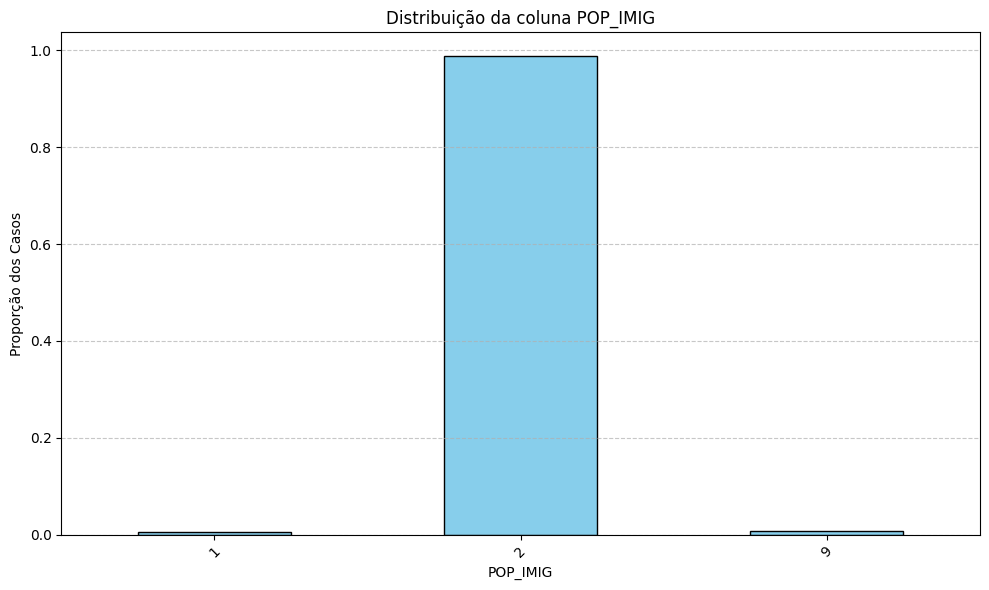

Atenção: A coluna 'BENEF_GOV' contém 1699 valores NaN.
Isso representa 2.05% do total de 82833 registros.


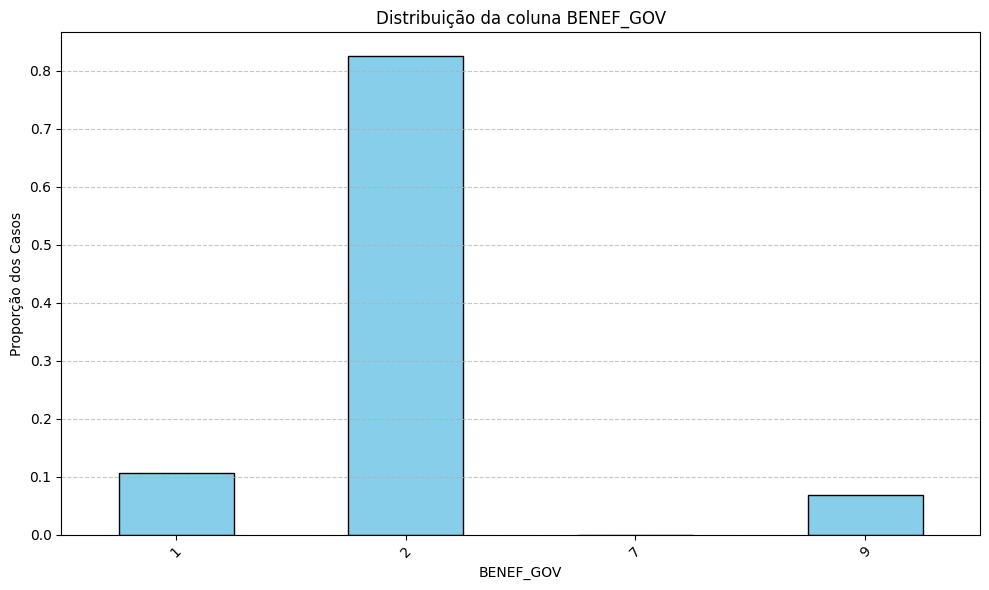

In [147]:
colunas_separadas = [
    'POP_LIBER', 'POP_RUA', 'POP_SAUDE', 'POP_IMIG', 'BENEF_GOV'
]

for coluna in colunas_separadas:
    checar_nan(df_cleaned_columns, nome_coluna=coluna)

As populações em geral tem pouquissimas amostras, vamos usar apenas **POP_LIBER** e **BENEF_GOV**

In [148]:
df_cleaned_columns = df_cleaned_columns.drop(columns=['POP_IMIG'])
df_cleaned_columns = df_cleaned_columns.drop(columns=['POP_RUA'])
df_cleaned_columns = df_cleaned_columns.drop(columns=['POP_SAUDE'])

In [149]:
df_cleaned_columns["POP_LIBER"] = pd.to_numeric(df_cleaned_columns["POP_LIBER"], errors="coerce")
df_cleaned_columns = df_cleaned_columns[df_cleaned_columns["POP_LIBER"].isin([1, 2])]

df_cleaned_columns["BENEF_GOV"] = pd.to_numeric(df_cleaned_columns["BENEF_GOV"], errors="coerce")
df_cleaned_columns = df_cleaned_columns[df_cleaned_columns["BENEF_GOV"].isin([1, 2])]

OUTROS AGRAVOS (AGRAVDROGA, AGRAVTABAC) varchar2(1) <br>
1. Sim <br>
2. Não <br>
9. Ignorado

In [150]:
df_cleaned_columns = df_cleaned_columns[df_cleaned_columns["AGRAVDROGA"].isin(['1', '2'])]
df_cleaned_columns = df_cleaned_columns[df_cleaned_columns["AGRAVTABAC"].isin(['1', '2'])]

In [151]:
df_cleaned_columns.columns

Index(['Unnamed: 0', 'NU_ANO', 'CS_SEXO', 'CS_RACA', 'FORMA', 'AGRAVAIDS',
       'AGRAVALCOO', 'AGRAVDIABE', 'AGRAVOUTRA', 'NU_CONTATO', 'TRATSUP_AT',
       'NU_COMU_EX', 'POP_LIBER', 'BENEF_GOV', 'AGRAVDROGA', 'AGRAVTABAC',
       'SITUACAO_AGRUPADA', 'REGIAO', 'IDADE_ANOS', 'ESCOL_CATEGORIZADA',
       'TEMPO_DE_NOTI', 'TEMPO_DE_INICIO_TRATAMENTO'],
      dtype='object')

### Dropando Tratsup_at

In [152]:
df_cleaned_columns = df_cleaned_columns.drop(columns=['TRATSUP_AT'])

In [153]:
df_cleaned_columns.columns

Index(['Unnamed: 0', 'NU_ANO', 'CS_SEXO', 'CS_RACA', 'FORMA', 'AGRAVAIDS',
       'AGRAVALCOO', 'AGRAVDIABE', 'AGRAVOUTRA', 'NU_CONTATO', 'NU_COMU_EX',
       'POP_LIBER', 'BENEF_GOV', 'AGRAVDROGA', 'AGRAVTABAC',
       'SITUACAO_AGRUPADA', 'REGIAO', 'IDADE_ANOS', 'ESCOL_CATEGORIZADA',
       'TEMPO_DE_NOTI', 'TEMPO_DE_INICIO_TRATAMENTO'],
      dtype='object')

## Agora vamos separar em dados categóricos e contínuos:

In [154]:
classificacao = ['CS_SEXO', 'CS_RACA', 'FORMA', 'AGRAVAIDS', 'AGRAVALCOO', 'AGRAVDIABE', 'AGRAVOUTRA',
                  'POP_LIBER', 'BENEF_GOV', 'AGRAVDROGA', 'AGRAVTABAC', 'REGIAO', 'ESCOL_CATEGORIZADA']

In [155]:
regressao = ['NU_ANO', 'NU_CONTATO', 'IDADE_ANOS', 'TEMPO_DE_NOTI', 'TEMPO_DE_INICIO_TRATAMENTO']

In [156]:
df_encoded = pd.get_dummies(df_cleaned_columns, columns=classificacao)

### Agora iremos dividir o dataset na seção de teste e na seçãod e treino

Para dividirmos o dataset na parte de treino e teste precisamos separar os dados em 80% de treino e 20% de teste, com a restrição de que todas as observações em teste devem ter uma notificação ('NU_ANO') após qualquer observação do dataset de treino.
<br><br>
Além disso precisamos balancear as observações em relação aos diferentes anos e observar a proporção da classe "SITUACAO_AGRUPADA" = 1 entre esses anos.

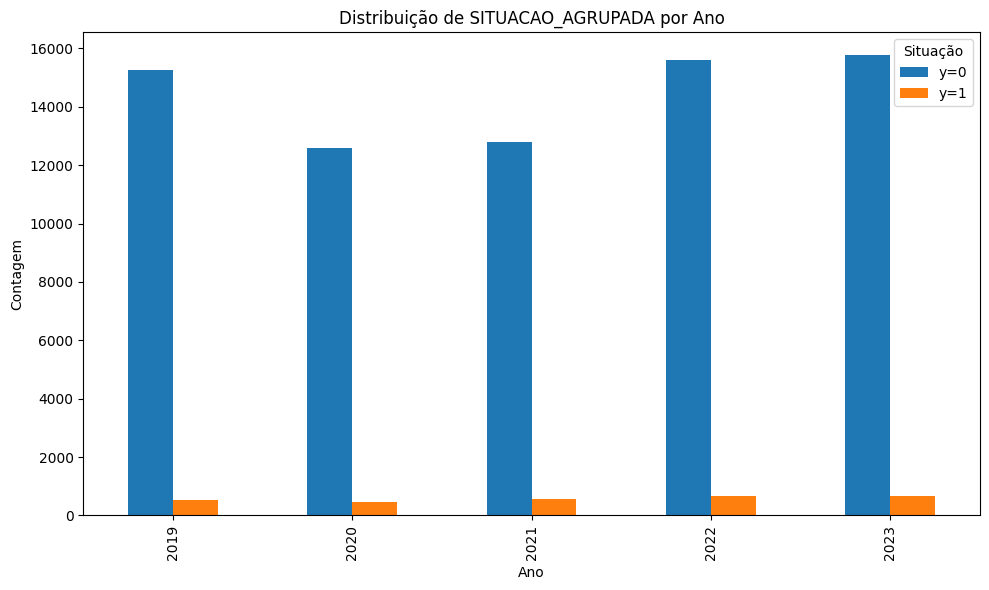

In [157]:
# 1. Agrupar por ano e alvo para o plot
counts = df_encoded.groupby(['NU_ANO', 'SITUACAO_AGRUPADA']).size().reset_index(name='COUNT')

# 2. Pivotear a tabela
pivot_counts = counts.pivot(index='NU_ANO', columns='SITUACAO_AGRUPADA', values='COUNT').fillna(0)

# Plot básico do histograma agrupado por ano e situação
pivot_counts.plot(kind='bar', figsize=(10, 6))

plt.title('Distribuição de SITUACAO_AGRUPADA por Ano')
plt.xlabel('Ano')
plt.ylabel('Contagem')
plt.legend(title='Situação', labels=['y=0', 'y=1'])
plt.tight_layout()
plt.show()


Agora vamos realizar uma divisão que tenha:<br>
1) Mesma quantidade de amostras por anos (para balancear essa classe)
2) Mesma proporção de amostras de colunas alvo entre os anos (para balancear essa classe dentre os anos)
3) Ter no máximo 21000 (para atender a demanda do enunciado de limite máximo)

In [158]:
# 1. Lista dos anos e quantidade desejada
anos = list(range(2019, 2024))
n_y1_por_ano = 416
total_y1 = n_y1_por_ano * len(anos)
total_max = 21000
total_y0 = total_max - total_y1
n_y0_por_ano = total_y0 // len(anos)

# 2. Separar amostras
df_y1 = df_encoded[df_encoded['SITUACAO_AGRUPADA'] == 1]
df_y0 = df_encoded[df_encoded['SITUACAO_AGRUPADA'] == 0]

# 3. Amostrar por ano
amostras = []

for ano in anos:
    y1_amostra = df_y1[df_y1['NU_ANO'] == ano].sample(n=n_y1_por_ano, random_state=42)
    y0_amostra = df_y0[df_y0['NU_ANO'] == ano].sample(n=n_y0_por_ano, random_state=42)
    amostras.append(pd.concat([y1_amostra, y0_amostra]))

# 4. Concatenar todas as amostras e embaralhar
df_balanced = pd.concat(amostras).sample(frac=1, random_state=42).reset_index(drop=True)

# 5. Verificação rápida
print("Distribuição balanceada por ano e target:")
print(df_balanced.groupby(['NU_ANO', 'SITUACAO_AGRUPADA']).size().unstack())

print("\nTamanho total:", len(df_balanced))

Distribuição balanceada por ano e target:
SITUACAO_AGRUPADA     0    1
NU_ANO                      
2019               3784  416
2020               3784  416
2021               3784  416
2022               3784  416
2023               3784  416

Tamanho total: 21000


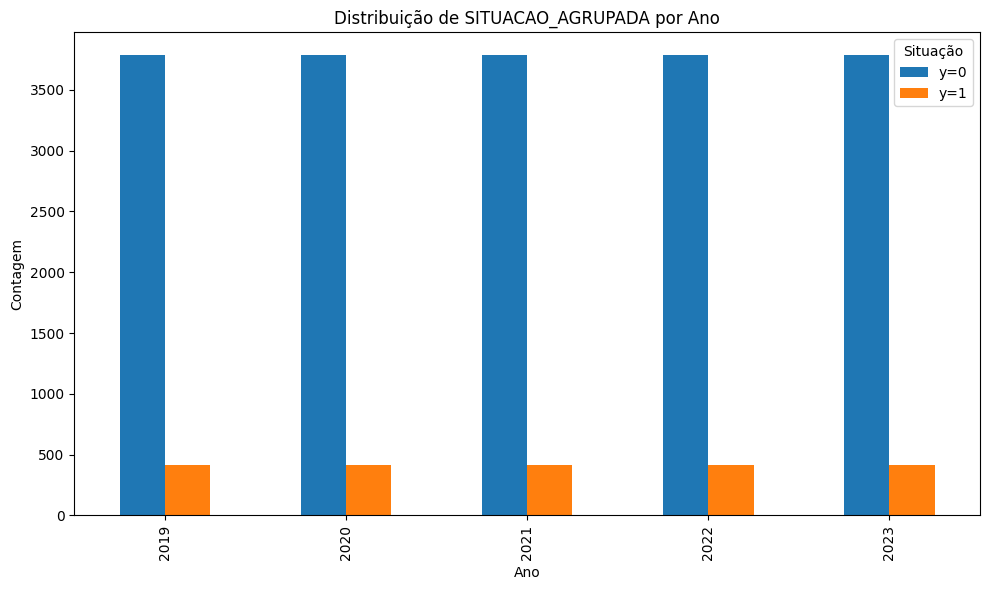

In [159]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Agrupar por ano e alvo para o plot
counts = df_balanced.groupby(['NU_ANO', 'SITUACAO_AGRUPADA']).size().reset_index(name='COUNT')

# 2. Pivotear a tabela
pivot_counts = counts.pivot(index='NU_ANO', columns='SITUACAO_AGRUPADA', values='COUNT').fillna(0)

# Plot básico do histograma agrupado por ano e situação
pivot_counts.plot(kind='bar', figsize=(10, 6))

plt.title('Distribuição de SITUACAO_AGRUPADA por Ano')
plt.xlabel('Ano')
plt.ylabel('Contagem')
plt.legend(title='Situação', labels=['y=0', 'y=1'])
plt.tight_layout()
plt.show()


Para separar a seção de treino e de teste agora basta separar o dataset em:
<br><br>
1. Dataset de teste: Amostras com ano de notificação sendo 2023 (pois são 20% do dataset original)
2. Dataset de treino: Amostras com ano de notificação anterior ao de 2023 (pois são 80% do dataset original)

In [160]:
y = df_balanced['SITUACAO_AGRUPADA']
X = df_balanced.drop(columns=['SITUACAO_AGRUPADA'])

In [161]:
# Separar o dataframe balanceado entre treino (anos < 2023) e teste (ano == 2023)
df_treino = df_balanced[df_balanced['NU_ANO'] < 2023]
df_teste = df_balanced[df_balanced['NU_ANO'] == 2023]

# Separar features e labels
X_train = df_treino.drop(columns=['SITUACAO_AGRUPADA'])
y_train = df_treino['SITUACAO_AGRUPADA']

X_test = df_teste.drop(columns=['SITUACAO_AGRUPADA'])
y_test = df_teste['SITUACAO_AGRUPADA']

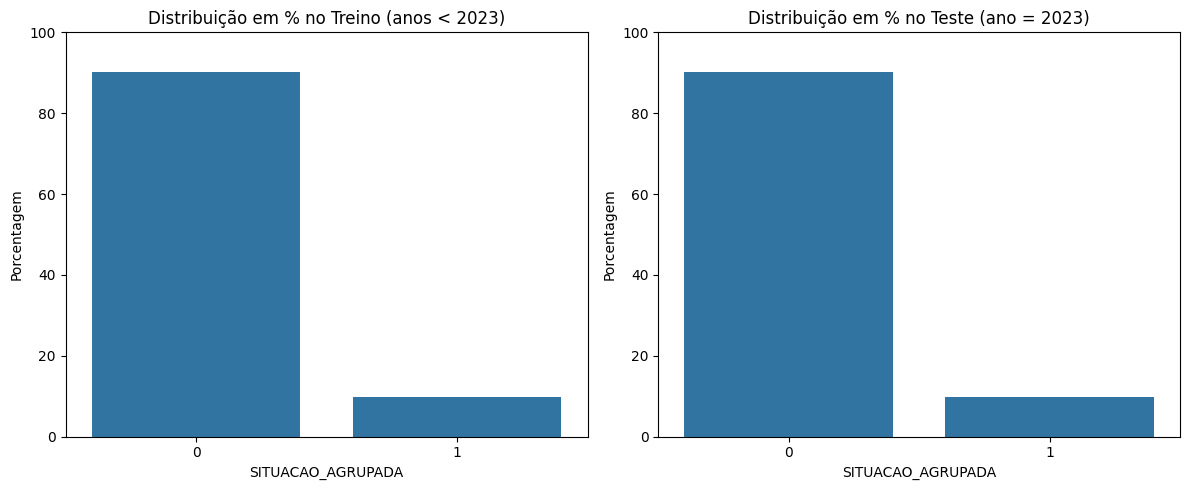

In [162]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# Calcular porcentagens
train_pct = y_train.value_counts(normalize=True).sort_index() * 100
test_pct = y_test.value_counts(normalize=True).sort_index() * 100

# Transformar em DataFrames para facilitar o plot
df_plot = pd.DataFrame({
    'Treino': train_pct,
    'Teste': test_pct
}).T  # Transpor para ficar (Treino, Teste) como linhas

# Plotar barras lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Treino
sns.barplot(x=df_plot.columns, y=df_plot.loc['Treino'], ax=axes[0])
axes[0].set_title('Distribuição em % no Treino (anos < 2023)')
axes[0].set_ylim(0, 100)
axes[0].set_xlabel('SITUACAO_AGRUPADA')
axes[0].set_ylabel('Porcentagem')

# Teste
sns.barplot(x=df_plot.columns, y=df_plot.loc['Teste'], ax=axes[1])
axes[1].set_title('Distribuição em % no Teste (ano = 2023)')
axes[1].set_ylim(0, 100)
axes[1].set_xlabel('SITUACAO_AGRUPADA')
axes[1].set_ylabel('Porcentagem')

plt.tight_layout()
plt.show()

In [163]:
def analisar_distribuicao(y, nome='y'):
    contagem = y.value_counts()
    proporcao = y.value_counts(normalize=True)

    resultado = pd.DataFrame({
        'Quantidade': contagem,
        'Proporção': proporcao
    })

    print(f'\nDistribuição de {nome}:')
    print(resultado)
    return resultado

# Análise das distribuições
analisar_distribuicao(y, nome='y')
analisar_distribuicao(y_train, nome='y_train')
analisar_distribuicao(y_test, nome='y_test')



Distribuição de y:
                   Quantidade  Proporção
SITUACAO_AGRUPADA                       
0                       18920   0.900952
1                        2080   0.099048

Distribuição de y_train:
                   Quantidade  Proporção
SITUACAO_AGRUPADA                       
0                       15136   0.900952
1                        1664   0.099048

Distribuição de y_test:
                   Quantidade  Proporção
SITUACAO_AGRUPADA                       
0                        3784   0.900952
1                         416   0.099048


,Quantidade,Proporção
SITUACAO_AGRUPADA,,
0,3784,0.900952
1,416,0.099048


In [164]:
X_train.columns

Index(['Unnamed: 0', 'NU_ANO', 'NU_CONTATO', 'NU_COMU_EX', 'IDADE_ANOS',
       'TEMPO_DE_NOTI', 'TEMPO_DE_INICIO_TRATAMENTO', 'CS_SEXO_F', 'CS_SEXO_M',
       'CS_RACA_1', 'CS_RACA_2', 'CS_RACA_4', 'FORMA_1', 'FORMA_2',
       'AGRAVAIDS_1.0', 'AGRAVAIDS_2.0', 'AGRAVALCOO_1.0', 'AGRAVALCOO_2.0',
       'AGRAVDIABE_1.0', 'AGRAVDIABE_2.0', 'AGRAVOUTRA_1.0', 'AGRAVOUTRA_2.0',
       'POP_LIBER_1.0', 'POP_LIBER_2.0', 'BENEF_GOV_1.0', 'BENEF_GOV_2.0',
       'AGRAVDROGA_1', 'AGRAVDROGA_2', 'AGRAVTABAC_1', 'AGRAVTABAC_2',
       'REGIAO_Centro-Oeste', 'REGIAO_Nordeste', 'REGIAO_Norte',
       'REGIAO_Sudeste', 'REGIAO_Sul', 'ESCOL_CATEGORIZADA_0',
       'ESCOL_CATEGORIZADA_1', 'ESCOL_CATEGORIZADA_2', 'ESCOL_CATEGORIZADA_3'],
      dtype='object')

In [165]:
pd.concat([X_train, y_train], axis=1).to_csv("dados_treino.csv", index=False)
pd.concat([X_test, y_test], axis=1).to_csv("dados_teste.csv", index=False)

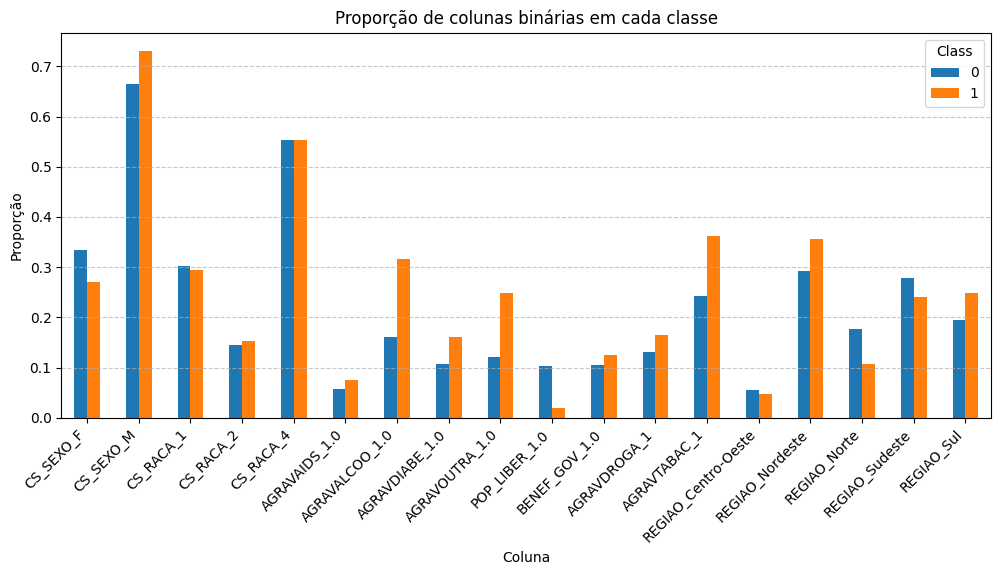

In [166]:
binary_columns = [
    'CS_SEXO_F', 'CS_SEXO_M', 'CS_RACA_1', 'CS_RACA_2', 'CS_RACA_4',
    'AGRAVAIDS_1.0', 'AGRAVALCOO_1.0',
    'AGRAVDIABE_1.0', 'AGRAVOUTRA_1.0', 'POP_LIBER_1.0',
    'BENEF_GOV_1.0','AGRAVDROGA_1',
    'AGRAVTABAC_1','REGIAO_Centro-Oeste', 'REGIAO_Nordeste',
    'REGIAO_Norte', 'REGIAO_Sudeste', 'REGIAO_Sul'
]

def plot_binary_columns_proportion(X, y, binary_columns, title="Proporção de colunas binárias em cada classe"):
    class_labels = y.unique()
    proportions = {col: X.groupby(y)[col].mean() for col in binary_columns}
    proportions_df = pd.DataFrame(proportions).T
    
    # Plot
    proportions_df.plot(kind='bar', figsize=(12, 5))
    
    plt.title(title)
    plt.xlabel("Coluna")
    plt.ylabel("Proporção")
    plt.xticks(rotation=45, ha='right')
    plt.legend(title="Class", labels=class_labels)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

plot_binary_columns_proportion(X_train, y_train, binary_columns)

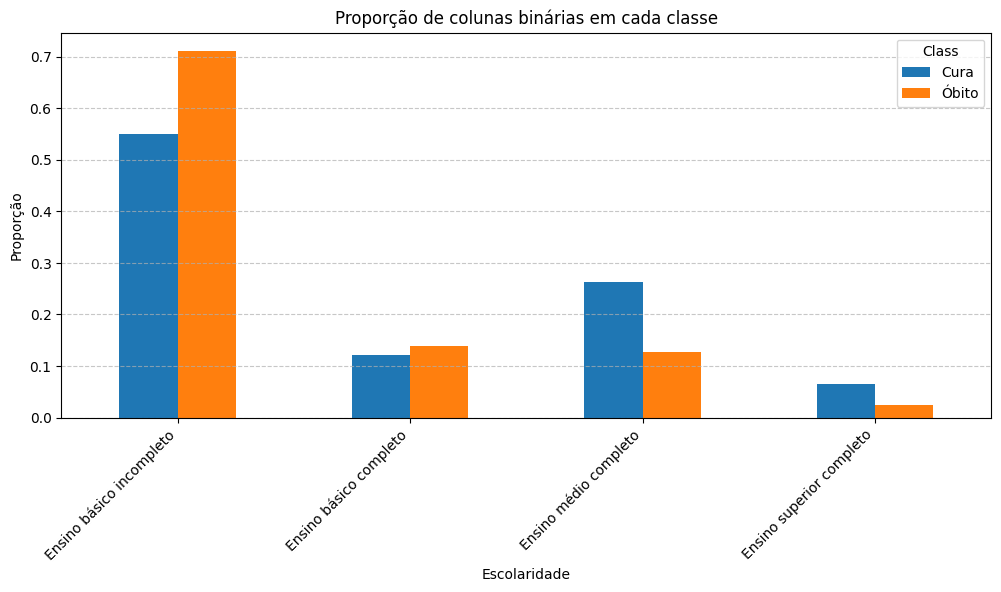

In [167]:
def plot_binary_columns_proportion(X, y, binary_columns, title="Proporção de colunas binárias em cada classe", columns=None, label="Colunas"):
    class_labels = y.unique()
    proportions = {col: X.groupby(y)[col].mean() for col in binary_columns}
    proportions_df = pd.DataFrame(proportions).T
    if columns is not None:
        proportions_df.index = columns
    # Plot
    proportions_df.plot(kind='bar', figsize=(12, 5))
    
    plt.title(title)
    plt.xlabel(label)
    plt.ylabel("Proporção")
    plt.xticks(rotation=45, ha='right')
    plt.legend(title="Class", labels=["Cura", "Óbito"])
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# Filtrar apenas as colunas binárias de escolaridade
binary_columns = ['ESCOL_CATEGORIZADA_0', 'ESCOL_CATEGORIZADA_1', 'ESCOL_CATEGORIZADA_2', 'ESCOL_CATEGORIZADA_3']
plot_binary_columns_proportion(X_train, y_train, binary_columns, columns=["Ensino básico incompleto", "Ensino básico completo", "Ensino médio completo", "Ensino superior completo"], label="Escolaridade")

In [168]:
# Contagem absoluta
contagem = df_filtra_ano['SITUACAO_AGRUPADA'].value_counts()

# Proporção relativa
proporcao = df_filtra_ano['SITUACAO_AGRUPADA'].value_counts(normalize=True)

# Juntando em um DataFrame
resultado = pd.DataFrame({
    'Quantidade': contagem,
    'Proporção': proporcao
})

print(resultado)


                   Quantidade  Proporção
SITUACAO_AGRUPADA                       
0                      299697   0.937139
1                       20103   0.062861
